<a href="https://colab.research.google.com/github/MelinaNk/PhD/blob/main/DSSAT_RESULTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
#%%script echo skipping
#Mount my Google Drive in the Colab notebook
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [74]:
#%%script echo skipping
#@title OS
import pandas as pd
import os
import numpy as np
os.chdir('/content/drive/MyDrive/Comparisons')

pdate='Dec_16'

DSSAT_directory = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS'
os.makedirs(DSSAT_directory, exist_ok=True)

DSSAT_summary_files_origin = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/SUMMARY_FILES/'+pdate+'/Original'
os.makedirs(DSSAT_summary_files_origin, exist_ok=True)

DSSAT_summary_files = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/SUMMARY_FILES/'+pdate
os.makedirs(DSSAT_summary_files_origin, exist_ok=True)

DSSAT_meteo_summary_files_origin = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/SUMMARY_FILES/'+pdate+'/Meteo/Original'
os.makedirs(DSSAT_meteo_summary_files_origin, exist_ok=True)

DSSAT_meteo_summary_files = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/SUMMARY_FILES/'+pdate+'/Meteo'
os.makedirs(DSSAT_meteo_summary_files, exist_ok=True)

In [75]:
#%%script echo skipping
#@title Summary files into CSV for comparing
import pandas as pd
import os
import numpy as np
os.chdir('/content/drive/MyDrive/Comparisons')



DSSAT_directory = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS'
os.makedirs(DSSAT_directory, exist_ok=True)

DSSAT_summary_files_origin = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/SUMMARY_FILES/'+pdate+'/Original'
os.makedirs(DSSAT_summary_files_origin, exist_ok=True)

DSSAT_summary_files = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/SUMMARY_FILES/'+pdate
os.makedirs(DSSAT_summary_files_origin, exist_ok=True)

# List all csv files in the directory
csv_files = [file for file in os.listdir(DSSAT_summary_files_origin) if file.endswith('.csv')]

# Process each csv file
for csv_file in sorted(csv_files):
    # Step 1: Read each csv file with the first row as column names
    csv_path = os.path.join(DSSAT_summary_files_origin, csv_file)
    csv_path_2 = os.path.join(DSSAT_summary_files, csv_file)
    df = pd.read_csv(csv_path, header=0)

    # Step 2: Keep only specified columns by index
    selected_columns_indices = [7, 10, 12, 13, 14, 15, 16, 17, 20]
    df = df.iloc[:, selected_columns_indices]

    # Step 3: Add a new column "Year" after the 2nd column
    df.insert(2, "Year", df.iloc[:, 2].astype(str).str[:4])

    # Step 4: Rename the first column to "EXNAME" and the second column to "WSTA"
    df = df.rename(columns={df.columns[0]: 'EXNAME', df.columns[1]: 'WSTA'})

    # Step 5: Add a new column "Scenario" based on WSTA.... values
    df['Scenario'] = df['WSTA'].apply(lambda x: 'rcp26' if '26' in str(x) else ('rcp45' if '45' in str(x) else ('rcp85' if '85' in str(x) else None)))

    # Step 6: Add a new column "Climate_model" based on the last two digits from the "WSTA" column
    df['Climate_model'] = 'Climate model ' + df['WSTA'].astype(str).apply(lambda x: x[-2:])

    # Conditions for rcp26
    conditions_rcp26 = [
        df['Climate_model'].astype(str).str.contains('Climate model 10|Climate model 11'),
        df['Climate_model'].astype(str).str.contains('Climate model 04|Climate model 07'),
        df['Climate_model'].astype(str).str.contains('Climate model 01|Climate model 02|Climate model 03|Climate model 05|Climate model 06|Climate model 08|Climate model 09')
    ]

    # Conditions for rcp45
    conditions_rcp45 = [
        df['Climate_model'].astype(str).str.contains('Climate model 11'),
        df['Climate_model'].astype(str).str.contains('Climate model 04|Climate model 05|Climate model 07'),
        df['Climate_model'].astype(str).str.contains('Climate model 01|Climate model 02|Climate model 03|Climate model 06|Climate model 08|Climate model 09|Climate model 10')
    ]

    # Conditions for rcp85
    conditions_rcp85 = [
        df['Climate_model'].astype(str).str.contains('Climate model 08|Climate model 10|Climate model 11'),
        df['Climate_model'].astype(str).str.contains('Climate model 04|Climate model 05|Climate model 07'),
        df['Climate_model'].astype(str).str.contains('Climate model 01|Climate model 02|Climate model 03|Climate model 06|Climate model 09')
    ]


    choices = ['top', 'low', 'other']

    # Use np.select to assign 'Rate' based on 'Scenario'
    df['Rate'] = np.select(
        [df['Scenario'] == 'rcp26', df['Scenario'] == 'rcp45', df['Scenario'] == 'rcp85'],
        [np.select(conditions_rcp26, ['top', 'low', 'other']),
        np.select(conditions_rcp45, ['top', 'low', 'other']),
        np.select(conditions_rcp85, ['top', 'low', 'other'])],
        default=None
    )
    df['Climate_model'] = df['Climate_model'].astype(str).str.replace('l 0', 'l ')


    # Step 7: Add a new column "Cultivar" based on the condition of the previous year's value
    df['Cultivar'] = 'Simeto'

    for index, row in df.iterrows():

        if int(row['Year']) < int(df.iloc[index - 1]['Year']):
            if df.iloc[index - 1]['Cultivar'] == 'Simeto':
                df.at[index, 'Cultivar'] = 'Mexicali'
            elif df.iloc[index - 1]['Cultivar'] == 'Mexicali':
                df.at[index, 'Cultivar'] = 'Sifnos'
        else:
            df.at[index, 'Cultivar'] = df.iloc[index - 1]['Cultivar']

    # Step 10: Add new columns ADAT_day, MDAT_day, and EDAT_day next to the Year column
    df.insert(3, 'EDAT_day', df['EDAT'].astype(str).str[-3:])
    df.insert(4, 'ADAT_day', df['ADAT'].astype(str).str[-3:])
    df.insert(5, 'MDAT_day', df['MDAT'].astype(str).str[-3:])
    df.insert(6, 'HDAT_day', df['HDAT'].astype(str).str[-3:])

    df['Location'] = os.path.splitext(csv_file)[0]


    # Step 8: Save back to the same csv file
    df.to_csv(csv_path_2, index=False)

In [76]:
#%%script echo skipping
#@title Summary files Meteo into CSV for comparing
import pandas as pd
import os
import numpy as np
os.chdir('/content/drive/MyDrive/Comparisons')


DSSAT_directory = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS'
os.makedirs(DSSAT_directory, exist_ok=True)

DSSAT_meteo_summary_files_origin = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/SUMMARY_FILES/'+pdate+'/Meteo/Original'
os.makedirs(DSSAT_meteo_summary_files_origin, exist_ok=True)

DSSAT_meteo_summary_files = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/SUMMARY_FILES/'+pdate+'/Meteo'
os.makedirs(DSSAT_meteo_summary_files, exist_ok=True)

# List all csv files in the directory
csv_files = [file for file in os.listdir(DSSAT_meteo_summary_files_origin) if file.endswith('.csv')]

# Process each csv file
for csv_file in sorted(csv_files):
    # Step 1: Read each csv file with the first row as column names
    csv_path = os.path.join(DSSAT_meteo_summary_files_origin, csv_file)
    csv_path_2 = os.path.join(DSSAT_meteo_summary_files, csv_file)
    df = pd.read_csv(csv_path, header=0)

    # Step 2: Keep only specified columns by index
    selected_columns_indices = [7, 10, 12, 13, 14, 15, 16, 17, 20]
    df = df.iloc[:, selected_columns_indices]

    # Step 3: Add a new column "Year" after the 2nd column
    df.insert(2, "Year", df.iloc[:, 2].astype(str).str[:4])

    # Step 4: Rename the first column to "EXNAME" and the second column to "WSTA"
    df = df.rename(columns={df.columns[0]: 'EXNAME', df.columns[1]: 'WSTA'})

    # Step 5: Add a new column "Scenario" based on WSTA.... values
    df['Scenario'] = 'Meteo'



    # Step 6: Add a new column "Climate_model" based on the last two digits from the "WSTA" column
    df['Climate_model'] = 'Meteo'

    df['Rate']='Observed'
    # Step 7: Add a new column "Cultivar" based on the condition of the previous year's value
    df['Cultivar'] = 'Simeto'

    for index, row in df.iterrows():

        if int(row['Year']) < int(df.iloc[index - 1]['Year']):
            if df.iloc[index - 1]['Cultivar'] == 'Simeto':
                df.at[index, 'Cultivar'] = 'Mexicali'
            elif df.iloc[index - 1]['Cultivar'] == 'Mexicali':
                df.at[index, 'Cultivar'] = 'Sifnos'
        else:
            df.at[index, 'Cultivar'] = df.iloc[index - 1]['Cultivar']

    # Step 10: Add new columns ADAT_day, MDAT_day, and EDAT_day next to the Year column
    df.insert(3, 'EDAT_day', df['EDAT'].astype(str).str[-3:])
    df.insert(4, 'ADAT_day', df['ADAT'].astype(str).str[-3:])
    df.insert(5, 'MDAT_day', df['MDAT'].astype(str).str[-3:])
    df.insert(6, 'HDAT_day', df['HDAT'].astype(str).str[-3:])

    df['Location'] = os.path.splitext(csv_file)[0]

    # Step 9: Remove rows with the same values in EDAT_day, ADAT_day, MDAT_day
    df = df.drop_duplicates(subset=['EDAT_day', 'ADAT_day', 'MDAT_day'], keep='first')



    # Step 8: Save back to the same csv file
    df.to_csv(csv_path_2, index=False)

In [77]:
#%%script echo skipping
#@title Combined data file
import os
import pandas as pd

# Directory containing CSV files
DSSAT_directory = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS'
os.makedirs(DSSAT_directory, exist_ok=True)


DSSAT_summary_files_origin = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/SUMMARY_FILES/'+pdate+'/Original'
os.makedirs(DSSAT_summary_files_origin, exist_ok=True)

DSSAT_summary_files = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/SUMMARY_FILES/'+pdate
os.makedirs(DSSAT_summary_files_origin, exist_ok=True)

DSSAT_meteo_summary_files_origin = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/SUMMARY_FILES/'+pdate+'/Meteo/Original'
os.makedirs(DSSAT_meteo_summary_files_origin, exist_ok=True)

DSSAT_meteo_summary_files = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/SUMMARY_FILES/'+pdate+'/Meteo'
os.makedirs(DSSAT_meteo_summary_files, exist_ok=True)

# List to store individual DataFrames
dfs = []

# Loop through each CSV file
for csv_file in sorted(os.listdir(DSSAT_meteo_summary_files)):
    if csv_file.endswith(".csv"):
        # Read the CSV file
        file_path = os.path.join(DSSAT_meteo_summary_files, csv_file)
        df = pd.read_csv(file_path)
        dfs.append(df)

# Loop through each CSV file
for csv_file in sorted(os.listdir(DSSAT_summary_files)):
    if csv_file.endswith(".csv"):
        # Read the CSV file
        file_path = os.path.join(DSSAT_summary_files, csv_file)
        df = pd.read_csv(file_path)
        dfs.append(df)



# Concatenate all DataFrames into one
combined_df = pd.concat(dfs, ignore_index=True)
# Filter out rows where Year is not 2023
combined_df = combined_df[combined_df['Year'] != 2023]

# Display the combined DataFrame
print(combined_df.head())

# Save the combined DataFrame to a new CSV file
file_path_result = os.path.join(DSSAT_directory, 'combined_data_'+pdate+'.csv')
combined_df.to_csv(file_path_result, index=False)


     EXNAME      WSTA  Year  EDAT_day  ADAT_day  MDAT_day  HDAT_day     SDAT  \
0  MXSF2623  STMT0623  2006       356       111       150       240  2006350   
1  MXSF2623  STMT0623  2007       362       109       150       240  2007350   
2  MXSF2623  STMT0623  2008       354       115       154       244  2008350   
3  MXSF2623  STMT0623  2009       355       108       149       239  2009350   
4  MXSF2623  STMT0623  2010       356       120       160       250  2010350   

      PDAT     EDAT     ADAT     MDAT     HDAT  HWAM Scenario Climate_model  \
0  2006350  2006356  2007111  2007150  2007240  8031    Meteo         Meteo   
1  2007350  2007362  2008109  2008150  2008240  7402    Meteo         Meteo   
2  2008350  2008354  2009115  2009154  2009244  8059    Meteo         Meteo   
3  2009350  2009355  2010108  2010149  2010239  8487    Meteo         Meteo   
4  2010350  2010356  2011120  2011160  2011250  7652    Meteo         Meteo   

       Rate  Cultivar         Location  
0  

In [78]:
#%%script echo skipping
#@title Combined data add Elevation
import pandas as pd

# Read the existing CSV file
DSSAT_directory = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS'
os.makedirs(DSSAT_directory, exist_ok=True)


combined_file_path = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_'+pdate+'.csv'
df = pd.read_csv(combined_file_path)

# Dictionary mapping locations to elevations
elevation_mapping = {'Amfikleia_urban': 440, 'Polydroso': 350, 'Amfikleia_rural': 245, 'Lefkochori': 133,
                     'Livadeia': 120, 'Kopaida': 98, 'Antikyra': 336, 'Kyriaki': 760}

# Add 'Elevation' column based on the mapping
df['Elevation'] = df['Location'].map(elevation_mapping)

# Save the updated DataFrame to a new CSV file
updated_combined_file_path = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_'+pdate+'.csv'
df.to_csv(updated_combined_file_path, index=False)

# Display the updated DataFrame
print(df.head())


     EXNAME      WSTA  Year  EDAT_day  ADAT_day  MDAT_day  HDAT_day     SDAT  \
0  MXSF2623  STMT0623  2006       356       111       150       240  2006350   
1  MXSF2623  STMT0623  2007       362       109       150       240  2007350   
2  MXSF2623  STMT0623  2008       354       115       154       244  2008350   
3  MXSF2623  STMT0623  2009       355       108       149       239  2009350   
4  MXSF2623  STMT0623  2010       356       120       160       250  2010350   

      PDAT     EDAT     ADAT     MDAT     HDAT  HWAM Scenario Climate_model  \
0  2006350  2006356  2007111  2007150  2007240  8031    Meteo         Meteo   
1  2007350  2007362  2008109  2008150  2008240  7402    Meteo         Meteo   
2  2008350  2008354  2009115  2009154  2009244  8059    Meteo         Meteo   
3  2009350  2009355  2010108  2010149  2010239  8487    Meteo         Meteo   
4  2010350  2010356  2011120  2011160  2011250  7652    Meteo         Meteo   

       Rate  Cultivar         Location  Elev

In [79]:
%%script echo skipping
#@title PLots
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Specify the DSSAT directory
DSSAT_directory = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS'
os.makedirs(DSSAT_directory, exist_ok=True)

# Combine all CSV files into a single DataFrame
all_files = glob.glob(os.path.join(DSSAT_directory, '*.csv'))
combined_df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)

# Set up Seaborn style for better aesthetics
sns.set(style="whitegrid")

# Create a scatter plot for rcp26
plt.figure(figsize=(10, 6))

# Filter data for rcp26
rcp26_data = combined_df[combined_df['Scenario'] == 'rcp26']
# Get unique years for x-axis ticks
unique_years = rcp26_data['Year'].unique()

# Create a color map for unique Climate_model values
color_map = sns.color_palette("viridis", n_colors=len(rcp26_data['Climate_model'].unique()))
color_dict = dict(zip(rcp26_data['Climate_model'].unique(), color_map))

# Create a marker map for unique Location values
markers = ['o', 's', '^', 'D', 'v','X','p','+']  # You can add more shapes if needed
marker_dict = dict(zip(rcp26_data['Location'].unique(), markers))

# Create handles for Climate_model legend
legend_handles = [mpatches.Patch(color=color_dict[model], label=model) for model in rcp26_data['Climate_model'].unique()]



# Iterate through unique locations in rcp26_data
for location in rcp26_data['Location'].unique():
    location_data = rcp26_data[rcp26_data['Location'] == location]

    # Use a unique symbol for each location
    symbol = marker_dict.get(location, 'o')  # Default to 'o' if not found

    # Use a unique color for each Climate_model
    location_data['Color'] = location_data['Climate_model'].map(color_dict)

    # Plot data for the current location
    plt.scatter(location_data['Year'], location_data['HWAM'], marker=symbol, label=location, color=location_data['Color'])

# Set x-axis ticks to include all unique years
plt.xticks(unique_years, rotation=45, ha='right')

# Set plot labels and title
plt.xlabel('Year')
plt.ylabel('HWAM')
plt.title('Scatter Plot for rcp26')


# Show legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 0), loc='lower left', title='Location', fontsize='small')
plt.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc='upper left', title='Climate Model', fontsize='small')


# Show the plot
plt.show()


skipping


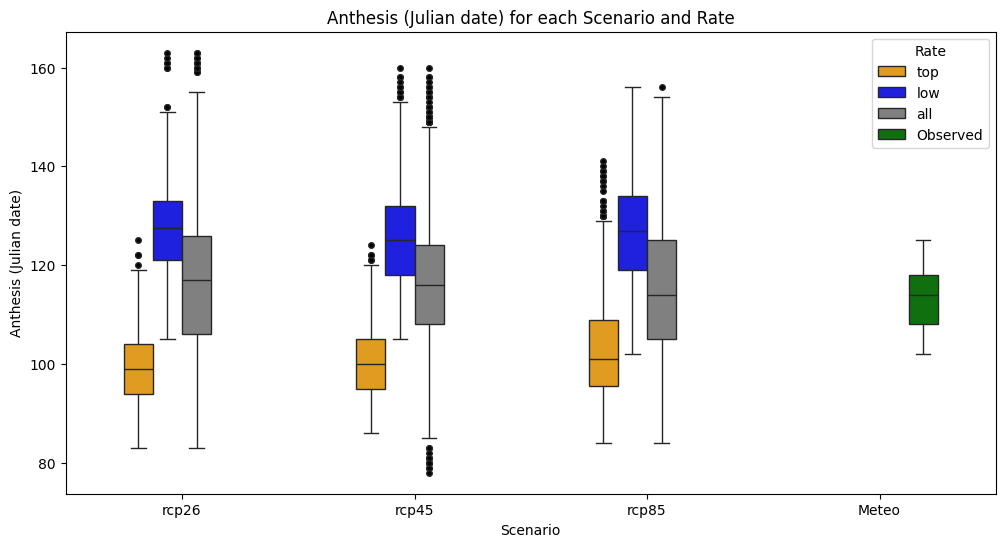

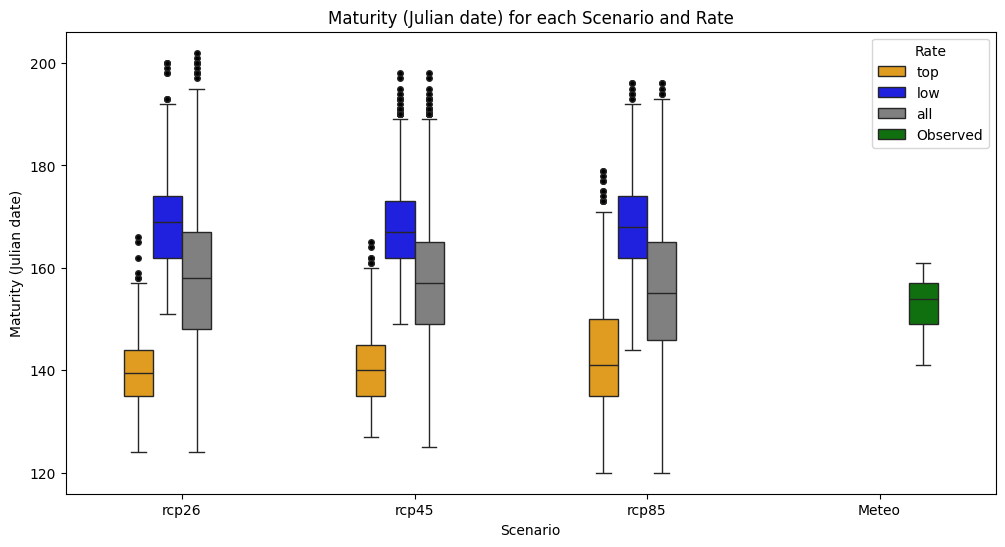

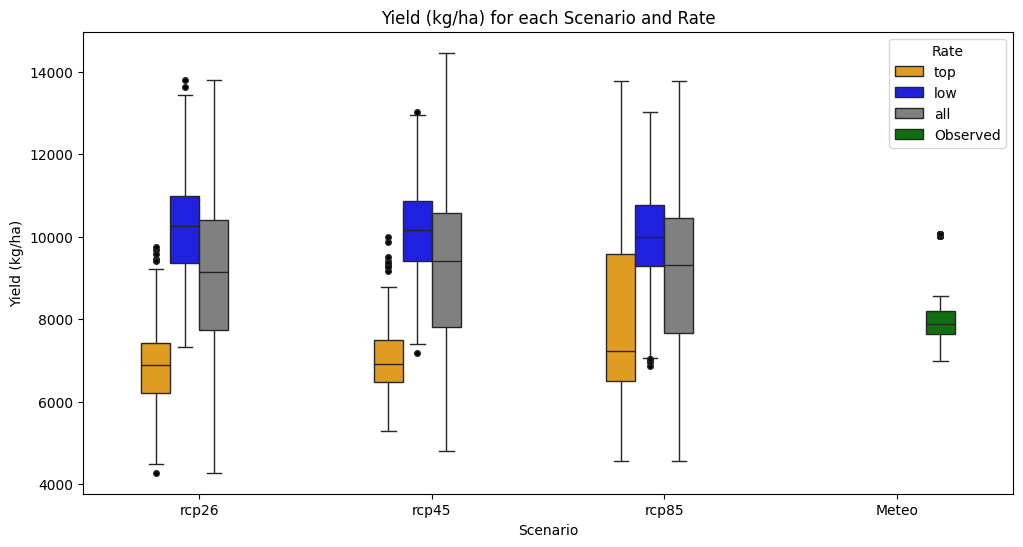

In [80]:
#%%script echo skipping
#@title BOXPLOTS according to top-low Rate for each Rate
import pandas as pd
import os
os.chdir('/content/drive/MyDrive/Comparisons')


import seaborn as sns
import matplotlib.pyplot as plt

# Directory containing CSV files
DSSAT_directory = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS'
os.makedirs(DSSAT_directory, exist_ok=True)

combined_file_path = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_'+pdate+'.csv'
graphs_path = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/Graphs/'+pdate
df = pd.read_csv(combined_file_path)

# Create a new DataFrame by concatenating Rate=top and Rate=low rows
new_df = pd.concat([df[df['Rate'] == 'top'], df[df['Rate'] == 'low']], ignore_index=True)

# Replace all values in the 'Rate' column with 'all'
df.loc[df['Rate'] != 'Observed', 'Rate'] = 'all'
# Create a new DataFrame by concatenating Rate=top and Rate=low rows
new_df2 = pd.concat([new_df,df], ignore_index=True)

# List of scenarios
scenarios = ['rcp26', 'rcp45', 'rcp85']

# Custom palette with 'top' as Orange and 'low' as Blue
custom_palette = {'top': 'orange', 'low': 'blue', 'Observed': 'green', 'all': 'grey'}

# Mapping of variables to y-axis labels
variable_labels = {'ADAT_day': 'Anthesis (Julian date)',
                   'MDAT_day': 'Maturity (Julian date)',
                   'HWAM': 'Yield (kg/ha)'}

# Iterate over variables
for i, column in enumerate(['ADAT_day', 'MDAT_day', 'HWAM'], start=1):
    plt.figure(figsize=(12, 6))

    # Define hue_order to ensure the correct order in the legend
    hue_order = ['top', 'low', 'all','Observed']

    sns.boxplot(x='Scenario', y=column, hue='Rate', data=new_df2, palette=custom_palette, hue_order=hue_order, showfliers=True, flierprops={'marker': 'o', 'markerfacecolor': 'black', 'markersize': 4}, width=0.5, dodge=True)
    plt.title(f'{variable_labels[column]} for each Scenario and Rate')
    plt.xlabel('Scenario')
    plt.ylabel(variable_labels[column])
    plt.legend(title='Rate')


    # Save the boxplot as an image in the same path as the CSV file
    boxplot_filename = f'{column}_boxplot.png'
    boxplot_filepath = os.path.join(graphs_path, boxplot_filename)
    plt.savefig(boxplot_filepath, bbox_inches='tight')

    plt.show()

<ipython-input-81-0a831b607b6e>:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  boxplot.set_xticklabels(boxplot.get_xticklabels(), rotation=45, ha='right', fontsize=8)


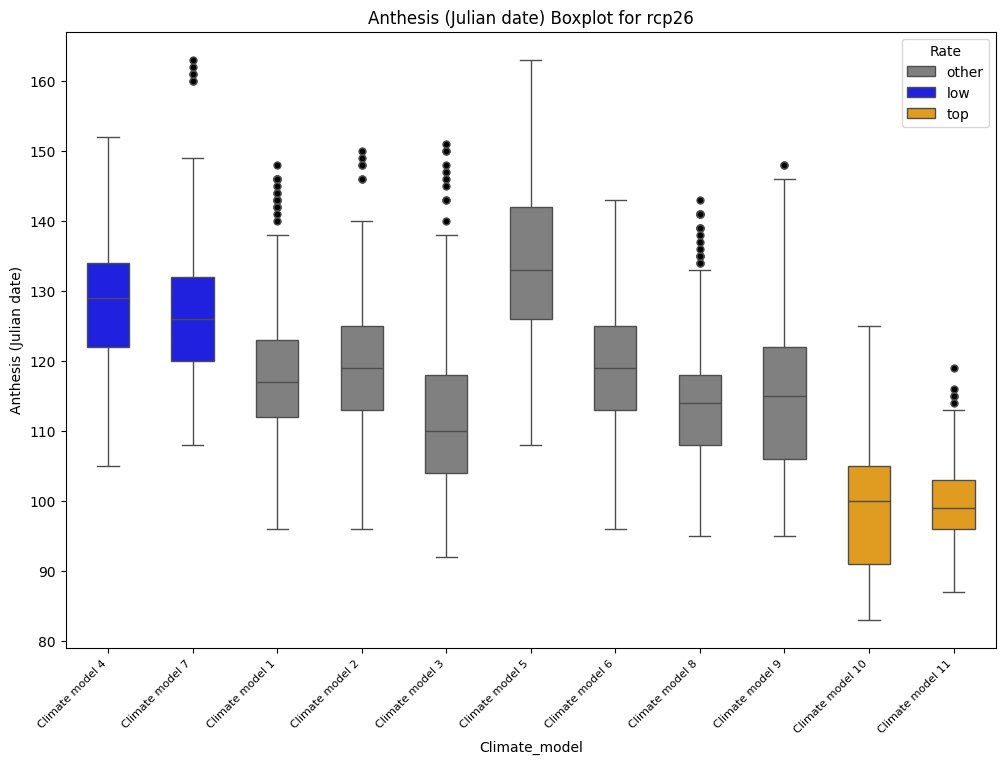

<ipython-input-81-0a831b607b6e>:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  boxplot.set_xticklabels(boxplot.get_xticklabels(), rotation=45, ha='right', fontsize=8)


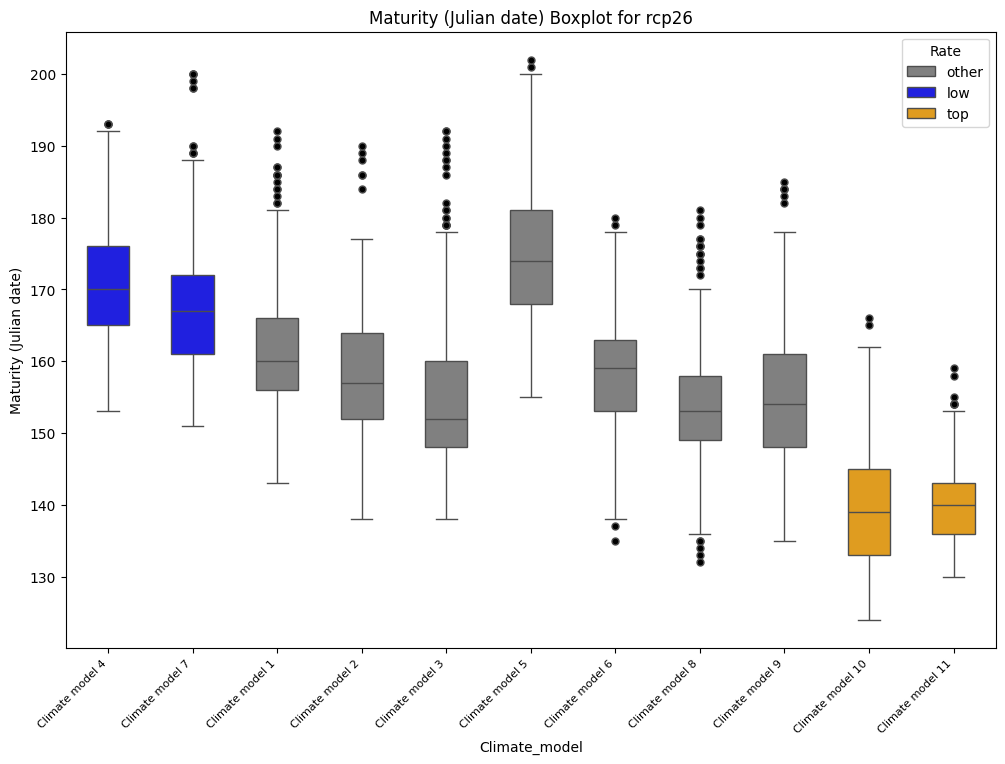

<ipython-input-81-0a831b607b6e>:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  boxplot.set_xticklabels(boxplot.get_xticklabels(), rotation=45, ha='right', fontsize=8)


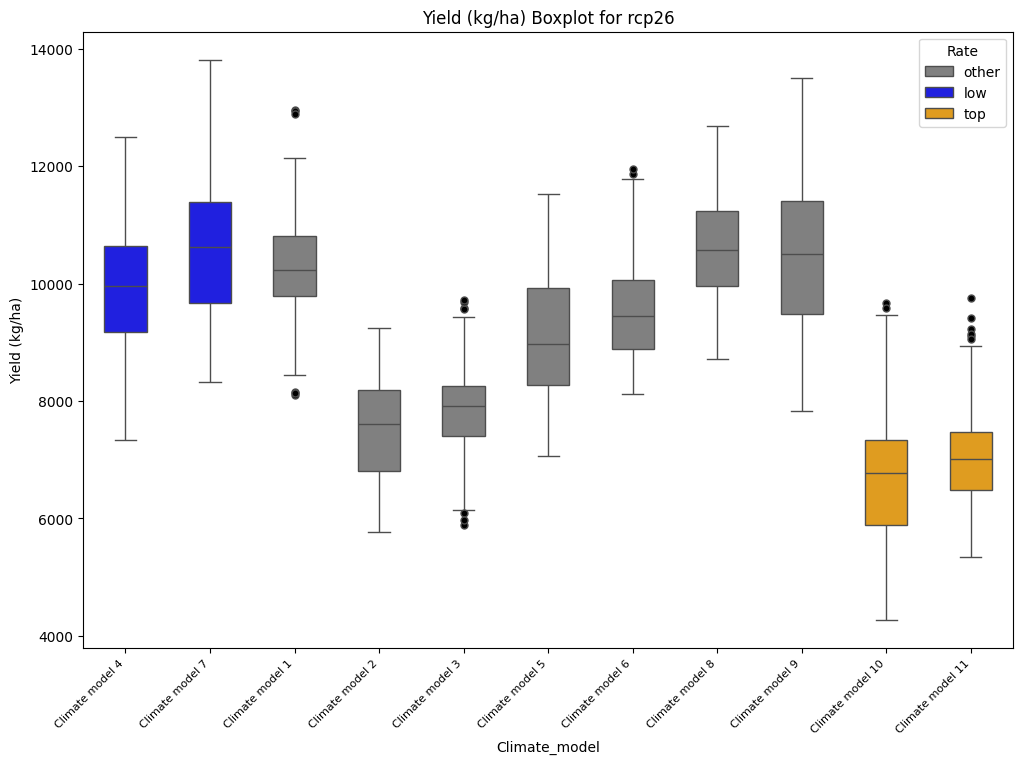

<ipython-input-81-0a831b607b6e>:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  boxplot.set_xticklabels(boxplot.get_xticklabels(), rotation=45, ha='right', fontsize=8)


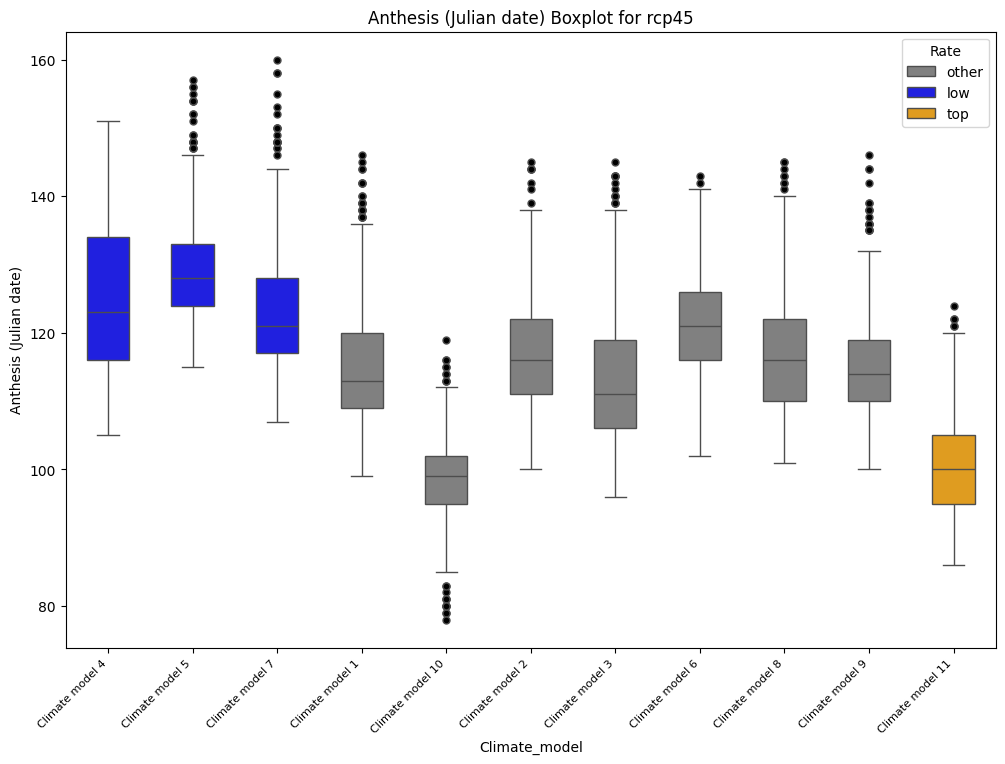

<ipython-input-81-0a831b607b6e>:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  boxplot.set_xticklabels(boxplot.get_xticklabels(), rotation=45, ha='right', fontsize=8)


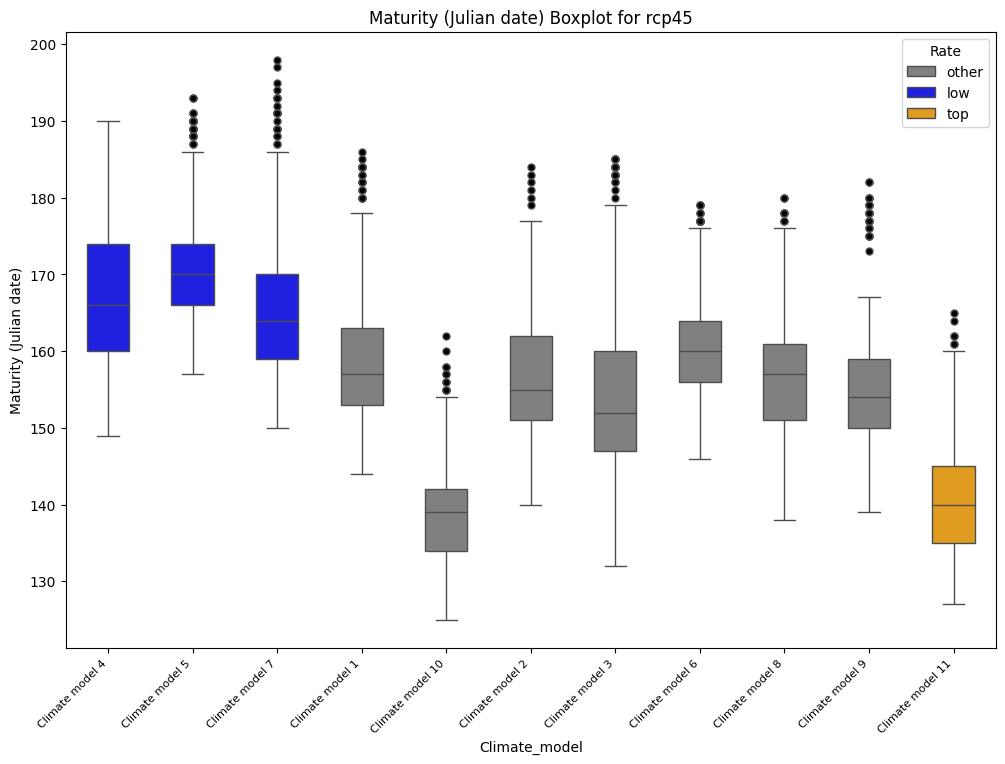

<ipython-input-81-0a831b607b6e>:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  boxplot.set_xticklabels(boxplot.get_xticklabels(), rotation=45, ha='right', fontsize=8)


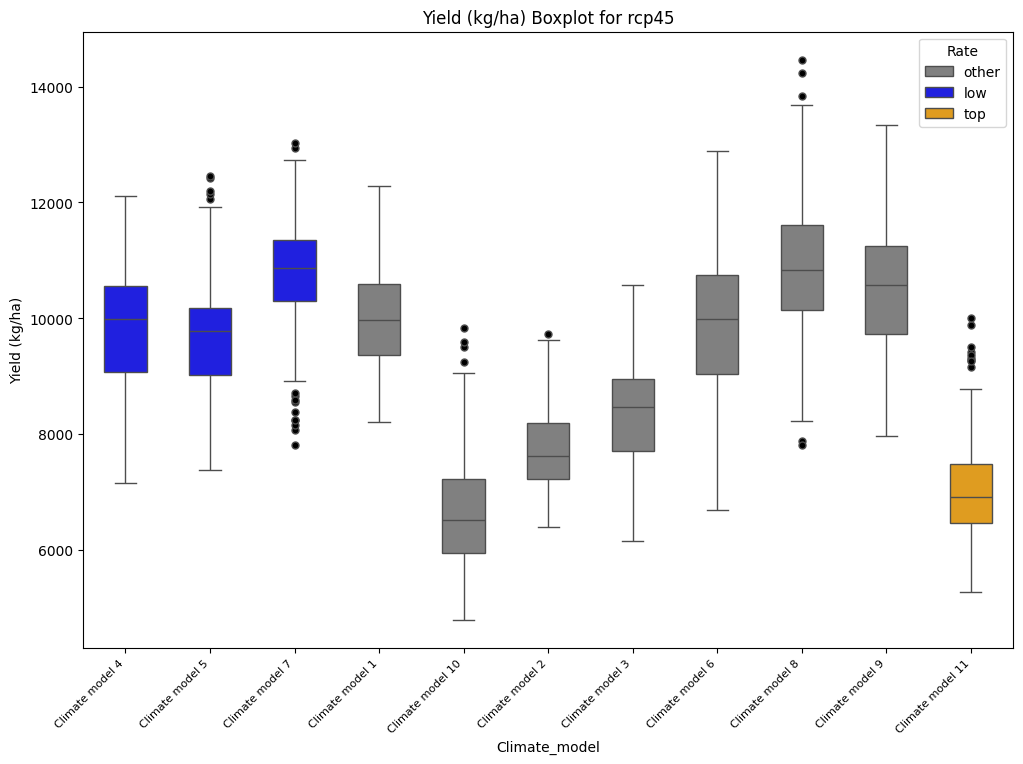

<ipython-input-81-0a831b607b6e>:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  boxplot.set_xticklabels(boxplot.get_xticklabels(), rotation=45, ha='right', fontsize=8)


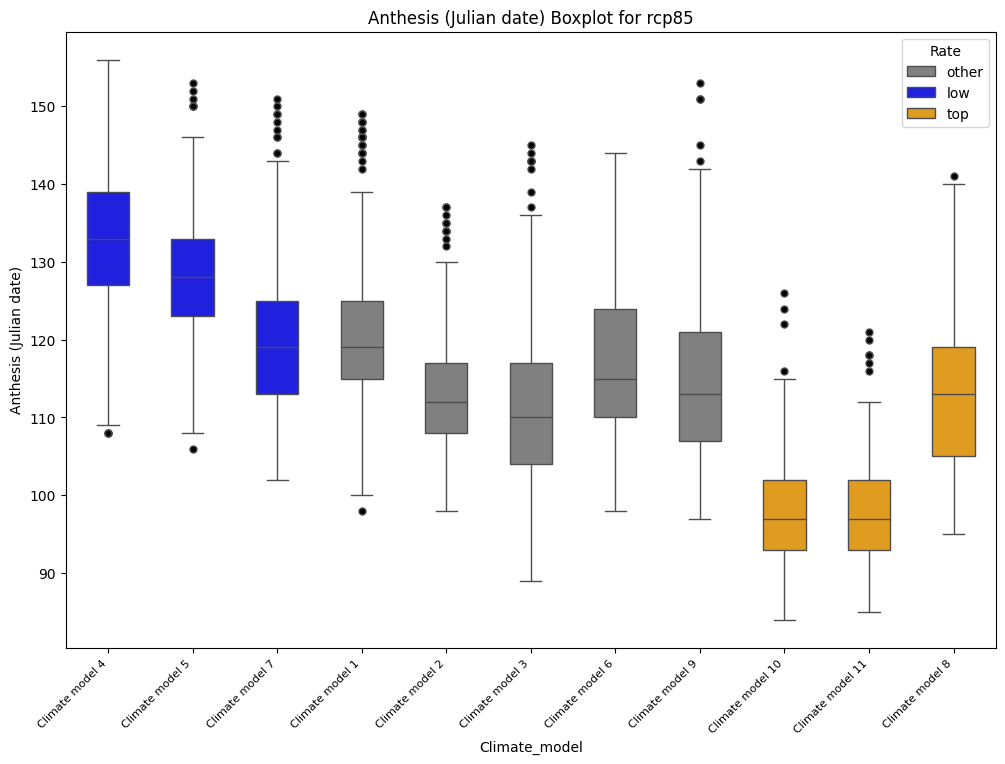

<ipython-input-81-0a831b607b6e>:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  boxplot.set_xticklabels(boxplot.get_xticklabels(), rotation=45, ha='right', fontsize=8)


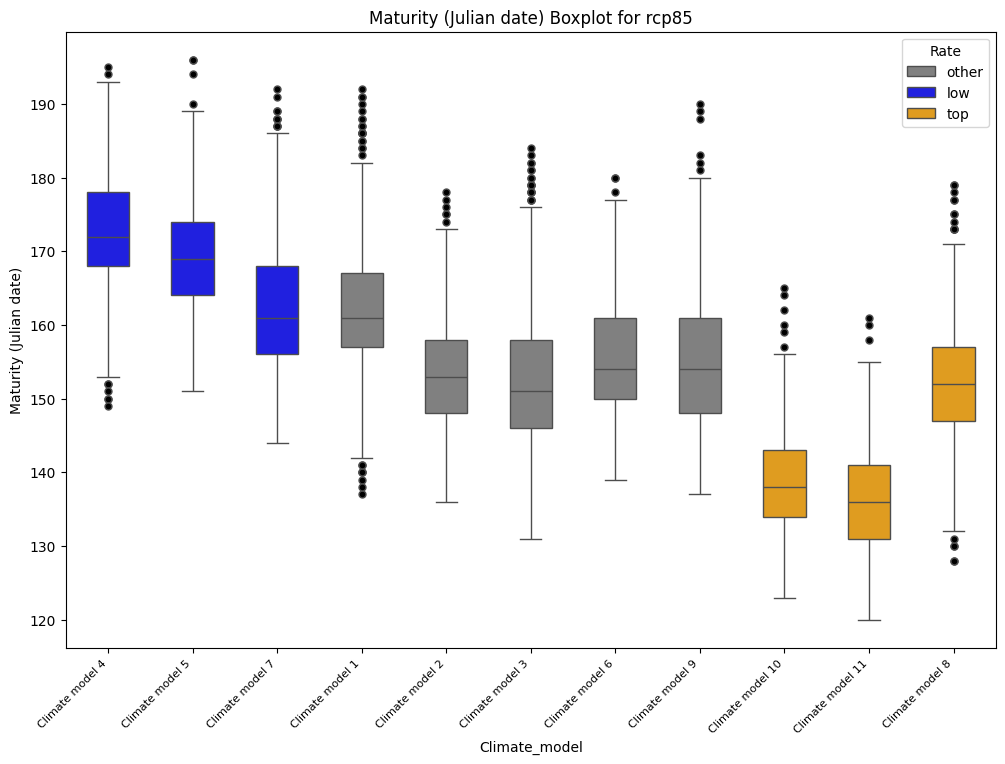

<ipython-input-81-0a831b607b6e>:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  boxplot.set_xticklabels(boxplot.get_xticklabels(), rotation=45, ha='right', fontsize=8)


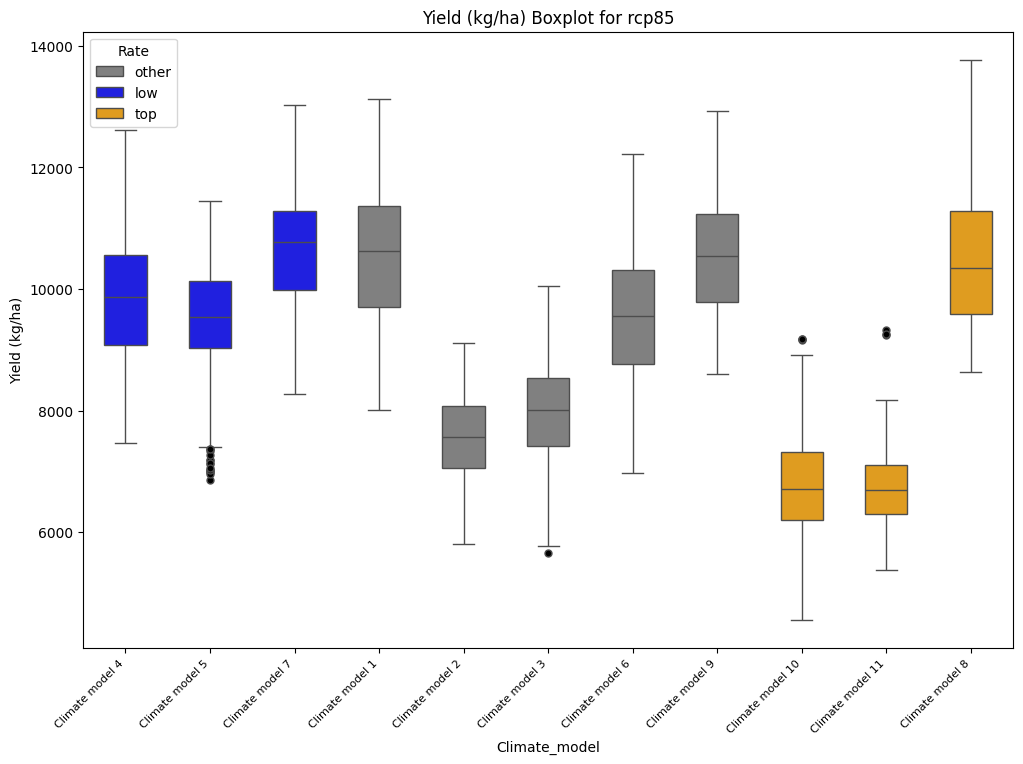

In [81]:
#%%script echo skipping
#@title BOXPLOTS according to top-low Rate for each Rate and each Cl Model
import pandas as pd
import os
os.chdir('/content/drive/MyDrive/Comparisons')


import seaborn as sns
import matplotlib.pyplot as plt

# Directory containing CSV files
DSSAT_directory = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS'
os.makedirs(DSSAT_directory, exist_ok=True)

combined_file_path = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_'+pdate+'.csv'
graphs_path = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/Graphs/'+pdate
df = pd.read_csv(combined_file_path)

# Custom palette with 'top' as Orange and 'low' as Blue
custom_palette = {'top': 'orange', 'low': 'blue', 'other':'grey'}

# Mapping of variables to y-axis labels
variable_labels = {'ADAT_day': 'Anthesis (Julian date)',
                   'MDAT_day': 'Maturity (Julian date)',
                   'HWAM': 'Yield (kg/ha)'}
# Define the order of Climate_model based on Rate
order_by_rate = df.groupby('Climate_model')['Rate'].max().sort_values().index

# List of scenarios
scenarios = ['rcp26', 'rcp45', 'rcp85']
# Create separate DataFrames for each scenario
df_rcp26 = df[df['Scenario'] == 'rcp26'].copy()
df_rcp45 = df[df['Scenario'] == 'rcp45'].copy()
df_rcp85 = df[df['Scenario'] == 'rcp85'].copy()

# Iterate over scenarios and DataFrames
for scenario, scenario_df in zip(scenarios, [df_rcp26, df_rcp45, df_rcp85]):

  # Iterate over variables
  for i, column in enumerate(['ADAT_day', 'MDAT_day', 'HWAM'], start=1):
      plt.figure(figsize=(12, 8))
      boxplot = sns.boxplot(x='Climate_model', y=column, hue='Rate', data=scenario_df, palette=custom_palette, showfliers=True, flierprops={'marker': 'o', 'markerfacecolor': 'black', 'markersize': 5}, width=0.5, order=scenario_df.groupby('Climate_model')['Rate'].max().sort_values().index)

      # Rotate x-axis labels by 45 degrees
      boxplot.set_xticklabels(boxplot.get_xticklabels(), rotation=45, ha='right', fontsize=8)

      plt.title(f'{variable_labels[column]} Boxplot for {scenario}')
      plt.xlabel('Climate_model')
      plt.ylabel(variable_labels[column])
      plt.legend(title='Rate')



      # Save the boxplot as an image in the same path as the CSV file with tight borders
      boxplot_filename = f'{column}_{scenario}_models_boxplot.png'
      boxplot_filepath = os.path.join(graphs_path, boxplot_filename)
      plt.savefig(boxplot_filepath, bbox_inches='tight')

      plt.show()

In [82]:
%%script echo skipping
#@title Regression plots according to top-low Rate and Year
import pandas as pd
import os
os.chdir('/content/drive/MyDrive/Comparisons')


import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Function to calculate metrics
def plot_regression_line_and_equation(x, y, label, color, text_x, text_y):
    model = LinearRegression()
    model.fit(x.values.reshape(-1, 1), y)
    line_x = np.linspace(x.min(), x.max(), 100)
    line_y = model.predict(line_x.reshape(-1, 1))

    # Plot regression line
    plt.plot(line_x, line_y, color=color, linestyle='--', label=f'{label}')

    # Display equation with custom position
    slope = model.coef_[0]
    intercept = model.intercept_
    equation = f"{label} = {slope:.4f}*Year + {intercept:.2f}"
    plt.text(text_x, text_y, equation, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',color=color)

# Directory containing CSV files
DSSAT_directory = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS'
os.makedirs(DSSAT_directory, exist_ok=True)

combined_file_path = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_'+pdate+'.csv'
graphs_path = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/Graphs/'+pdate
df = pd.read_csv(combined_file_path)

# List of scenarios
scenarios = ['rcp26', 'rcp45', 'rcp85']


# Mapping of variables to y-axis labels
variable_labels = {'ADAT_day': 'Anthesis (Julian date)',
                   'MDAT_day': 'Maturity (Julian date)',
                   'HWAM': 'Yield (kg/ha)'}


for scenario in scenarios:
    for column in ['ADAT_day', 'MDAT_day', 'HWAM']:
        plt.figure(figsize=(12, 8))
        # Create scatter plot for 'top' Rate

        sns.scatterplot(x='Year', y=column, data=df[df['Rate'] == 'top'], color='orange', label='Top Rate', s=60, alpha=0.7, edgecolor='black')
        plot_regression_line_and_equation(df[df['Rate'] == 'top']['Year'], df[df['Rate'] == 'top'][column], 'Top', 'orange', text_x=0.1, text_y=0.94)

        # Create scatter plot for 'low' Rate
        sns.scatterplot(x='Year', y=column, data=df[df['Rate'] == 'low'], color='blue', label='Low Rate', s=30, alpha=0.7, edgecolor='black', marker='^')
        plot_regression_line_and_equation(df[df['Rate'] == 'low']['Year'], df[df['Rate'] == 'low'][column], 'Low', 'blue', text_x=0.1, text_y=0.98)

        sns.scatterplot(x='Year', y=column, data=df[df['Rate'] == 'other'], color='grey', label='No Rate', s=30, alpha=0.7, edgecolor='black', marker='x')
        plot_regression_line_and_equation(df['Year'], df[column], 'All', 'black', text_x=0.1, text_y=0.96)

        plt.title('Scatter Plot for '+variable_labels[column]+' '+scenario)
        plt.xlabel('Year')
        plt.ylabel(variable_labels[column])  # Replace 'Your_Y_Column' with the actual column name you want on the y-axis

        # Set x-axis ticks as integers
        plt.xticks(df['Year'].unique().astype(int))

        # Rotate and make y-axis ticks smaller
        plt.yticks(fontsize='small')

        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()

        # Save the plot
        plot_filename = column+'_'+scenario+'_'+'scatter.png'
        plot_filepath = os.path.join(graphs_path, plot_filename)
        plt.savefig(plot_filepath, dpi=600)
        plt.show()
        plt.close()

skipping


/usr/local/lib/python3.10/dist-packages/seaborn/relational.py:433: UserWarning: You passed a edgecolor/edgecolors ('grey') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  points = ax.scatter(x=x, y=y, **kws)


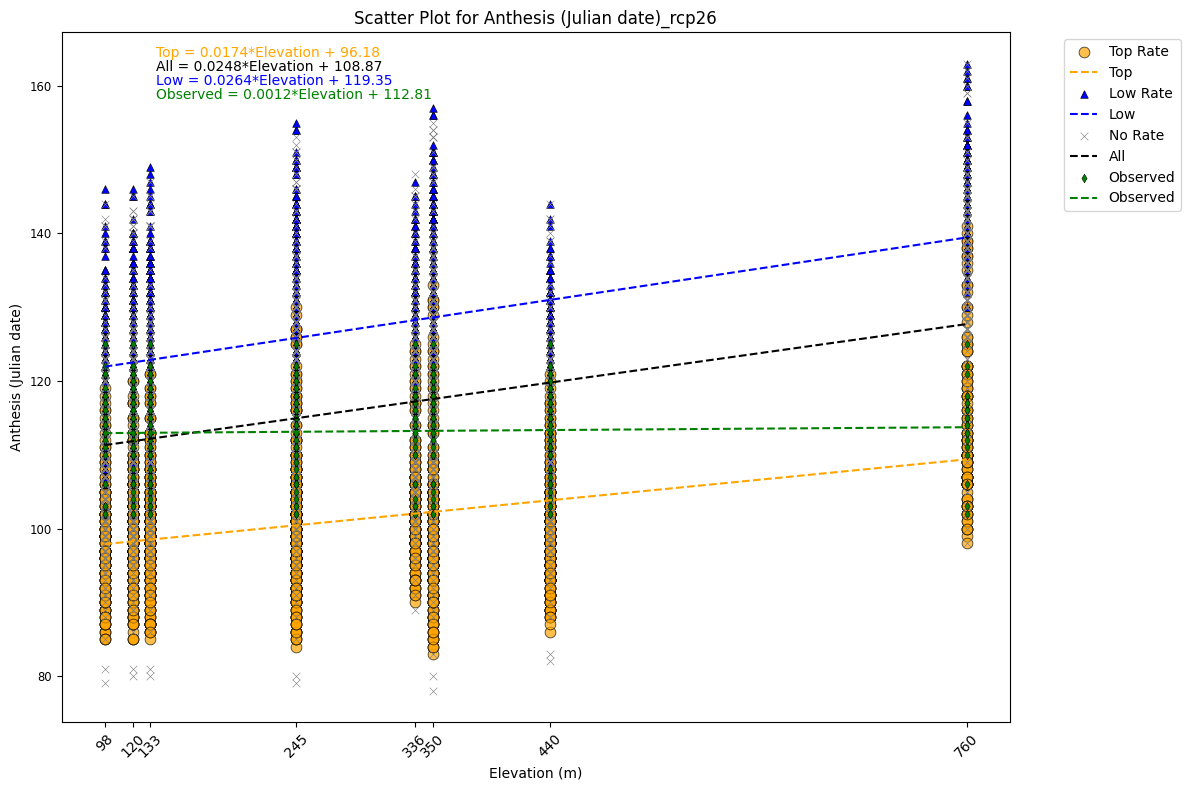

/usr/local/lib/python3.10/dist-packages/seaborn/relational.py:433: UserWarning: You passed a edgecolor/edgecolors ('grey') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  points = ax.scatter(x=x, y=y, **kws)


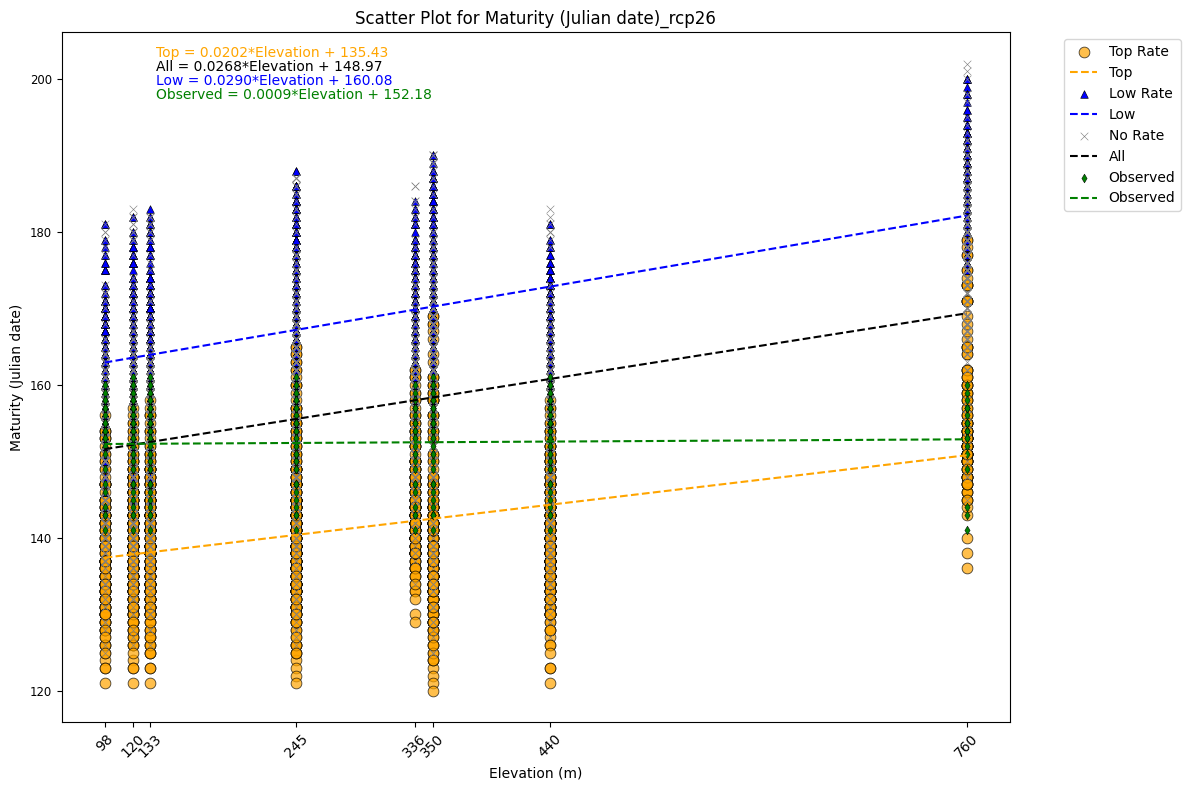

/usr/local/lib/python3.10/dist-packages/seaborn/relational.py:433: UserWarning: You passed a edgecolor/edgecolors ('grey') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  points = ax.scatter(x=x, y=y, **kws)


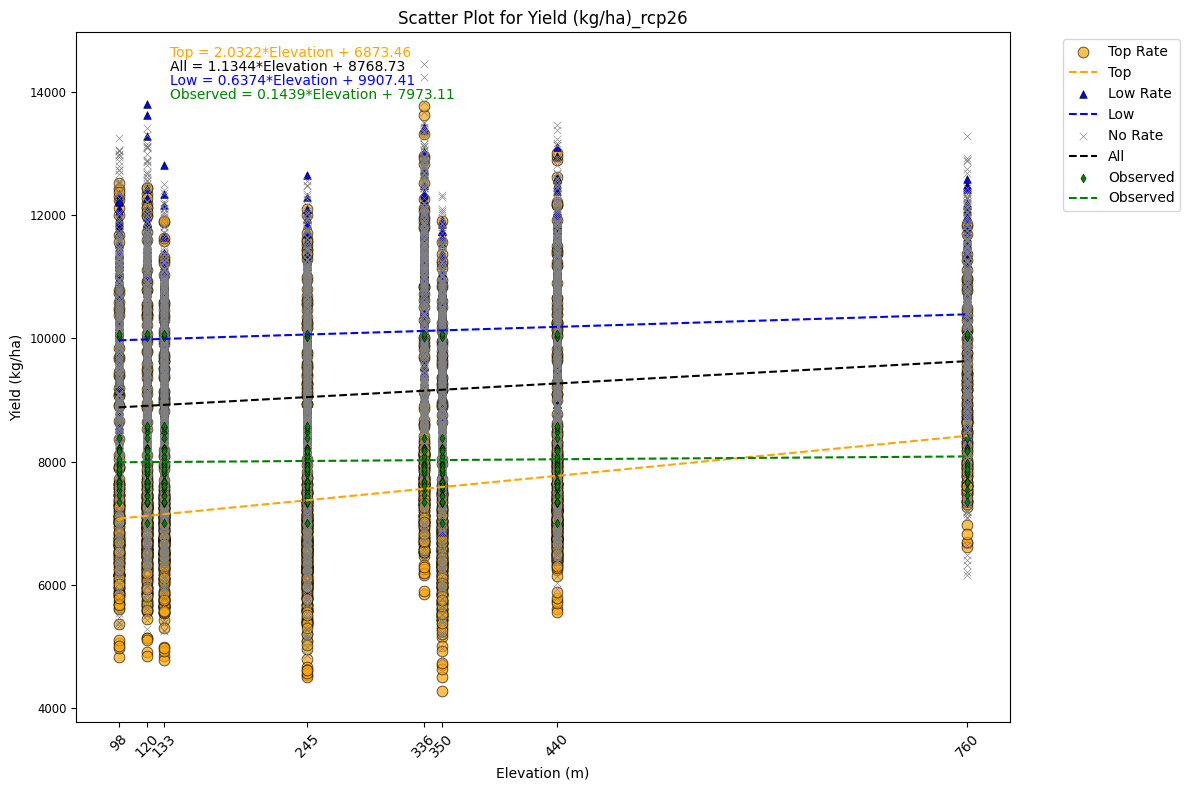

/usr/local/lib/python3.10/dist-packages/seaborn/relational.py:433: UserWarning: You passed a edgecolor/edgecolors ('grey') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  points = ax.scatter(x=x, y=y, **kws)


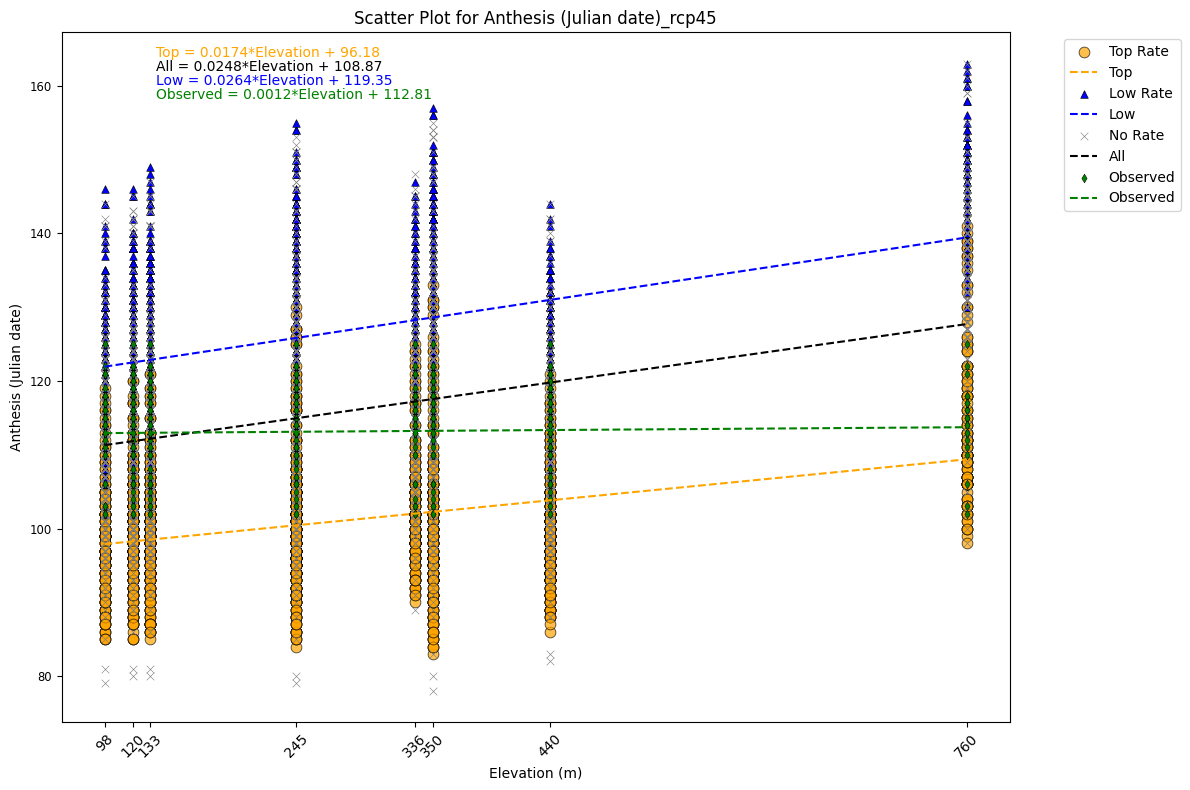

/usr/local/lib/python3.10/dist-packages/seaborn/relational.py:433: UserWarning: You passed a edgecolor/edgecolors ('grey') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  points = ax.scatter(x=x, y=y, **kws)


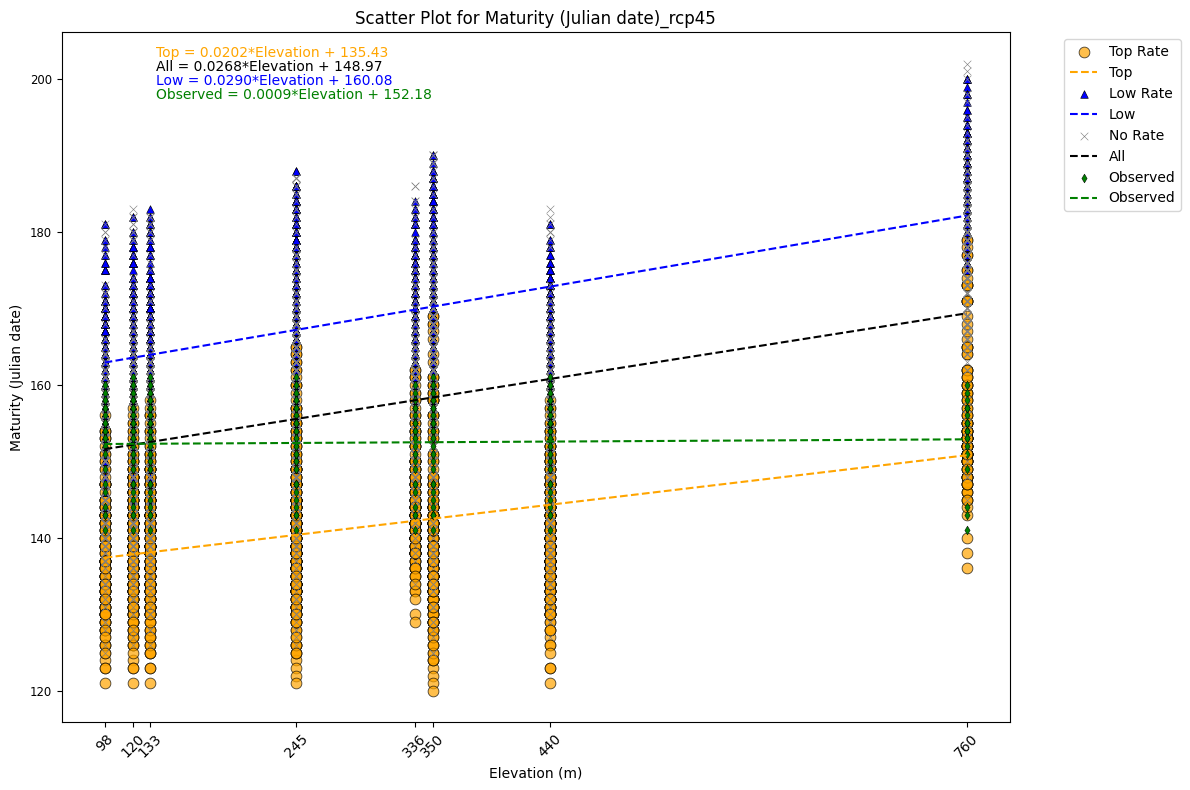

/usr/local/lib/python3.10/dist-packages/seaborn/relational.py:433: UserWarning: You passed a edgecolor/edgecolors ('grey') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  points = ax.scatter(x=x, y=y, **kws)


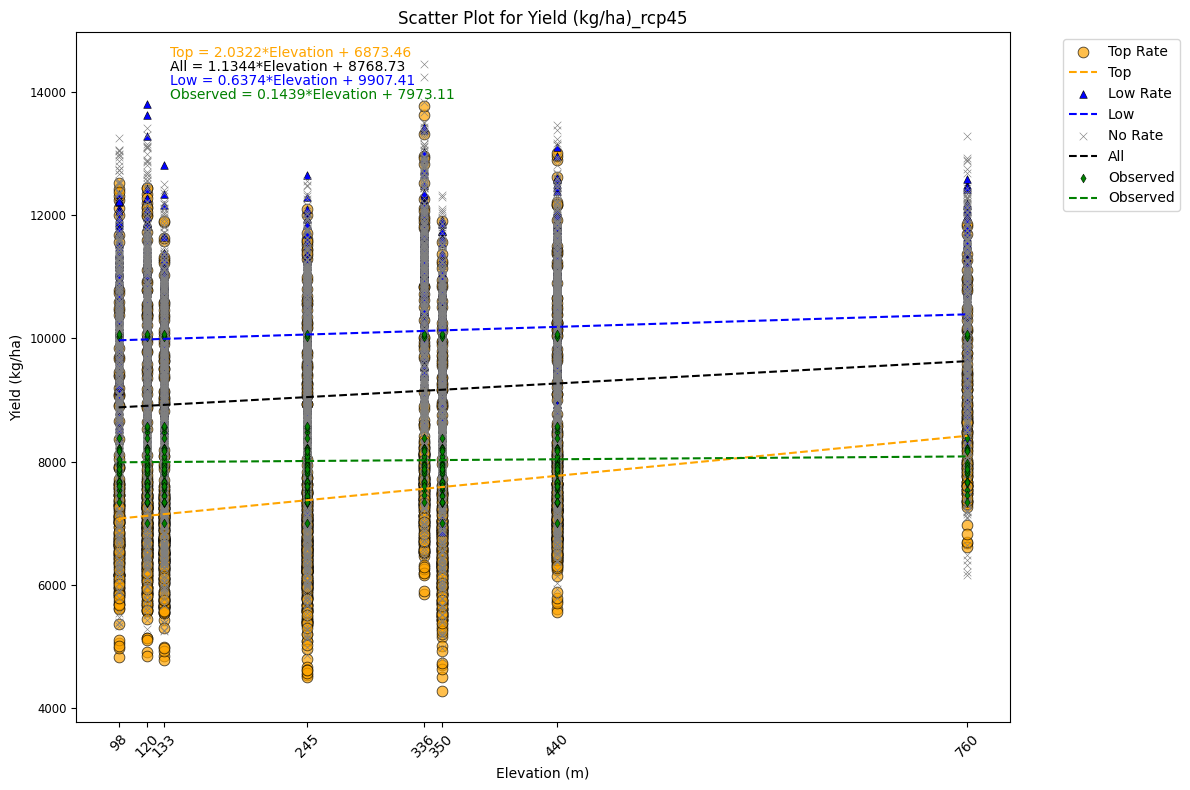

/usr/local/lib/python3.10/dist-packages/seaborn/relational.py:433: UserWarning: You passed a edgecolor/edgecolors ('grey') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  points = ax.scatter(x=x, y=y, **kws)


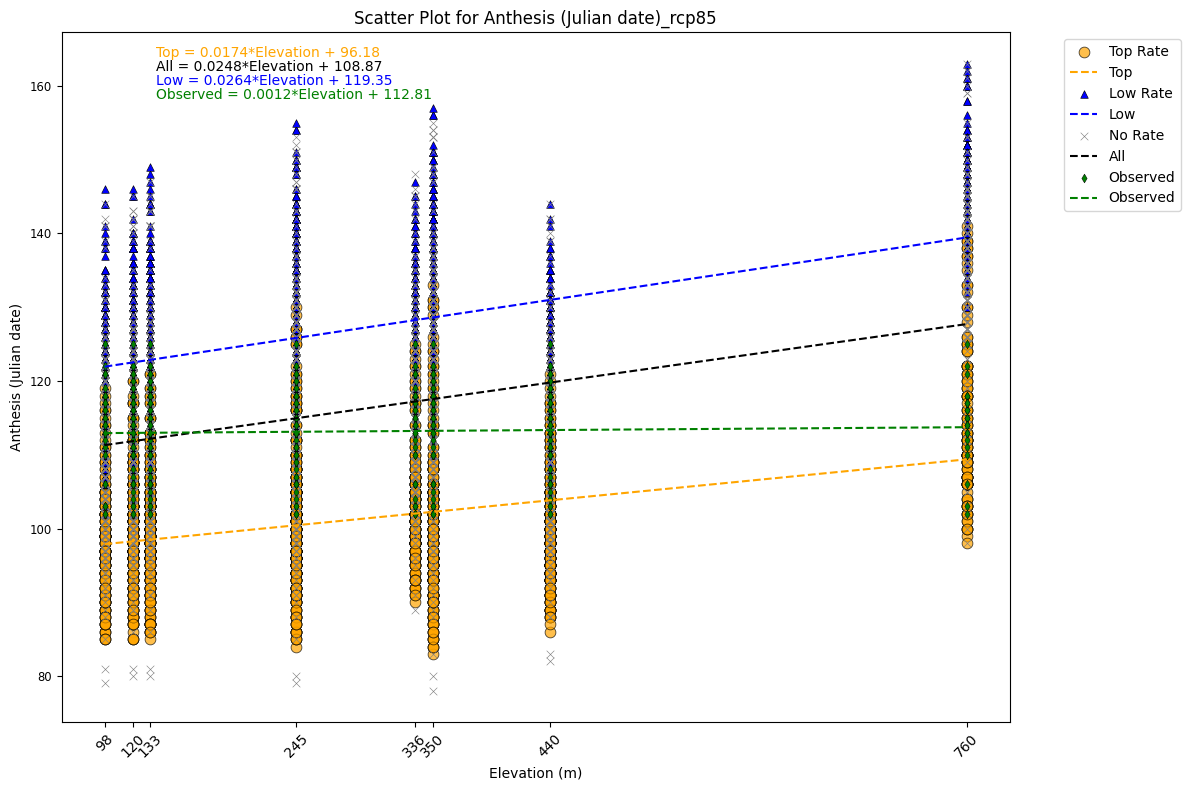

/usr/local/lib/python3.10/dist-packages/seaborn/relational.py:433: UserWarning: You passed a edgecolor/edgecolors ('grey') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  points = ax.scatter(x=x, y=y, **kws)


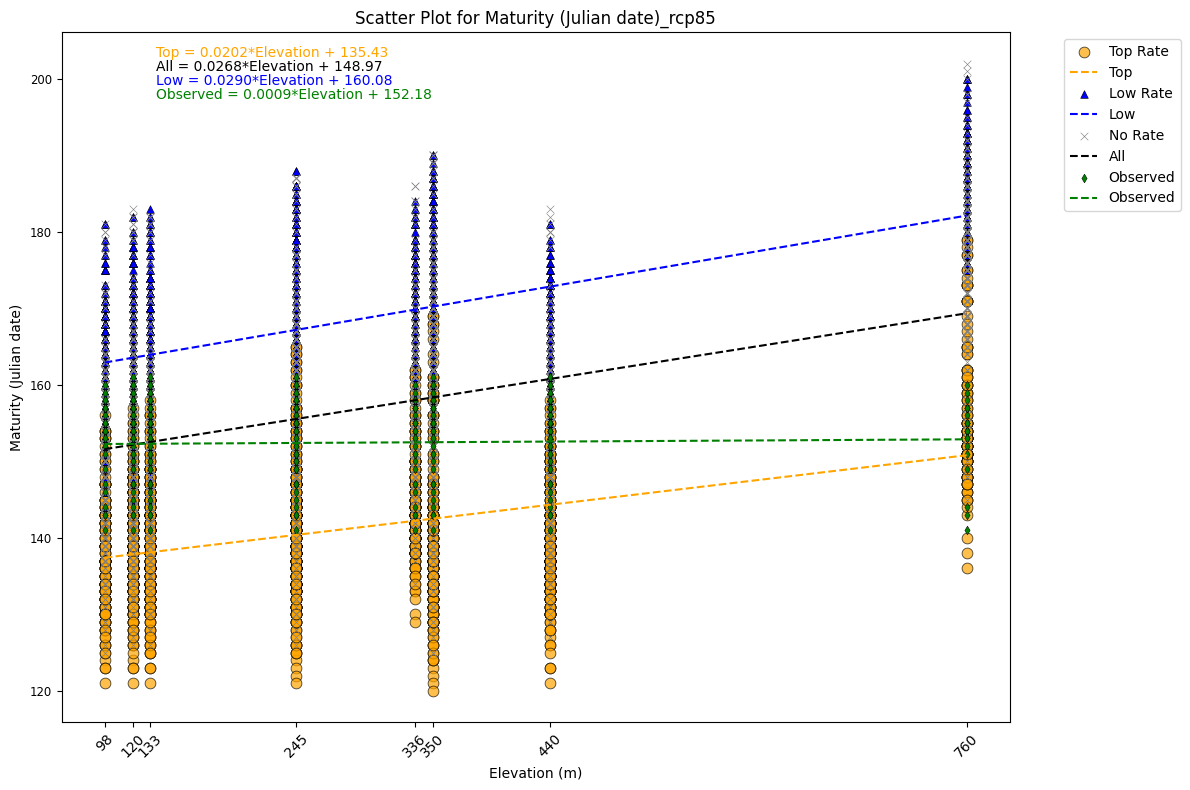

/usr/local/lib/python3.10/dist-packages/seaborn/relational.py:433: UserWarning: You passed a edgecolor/edgecolors ('grey') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  points = ax.scatter(x=x, y=y, **kws)


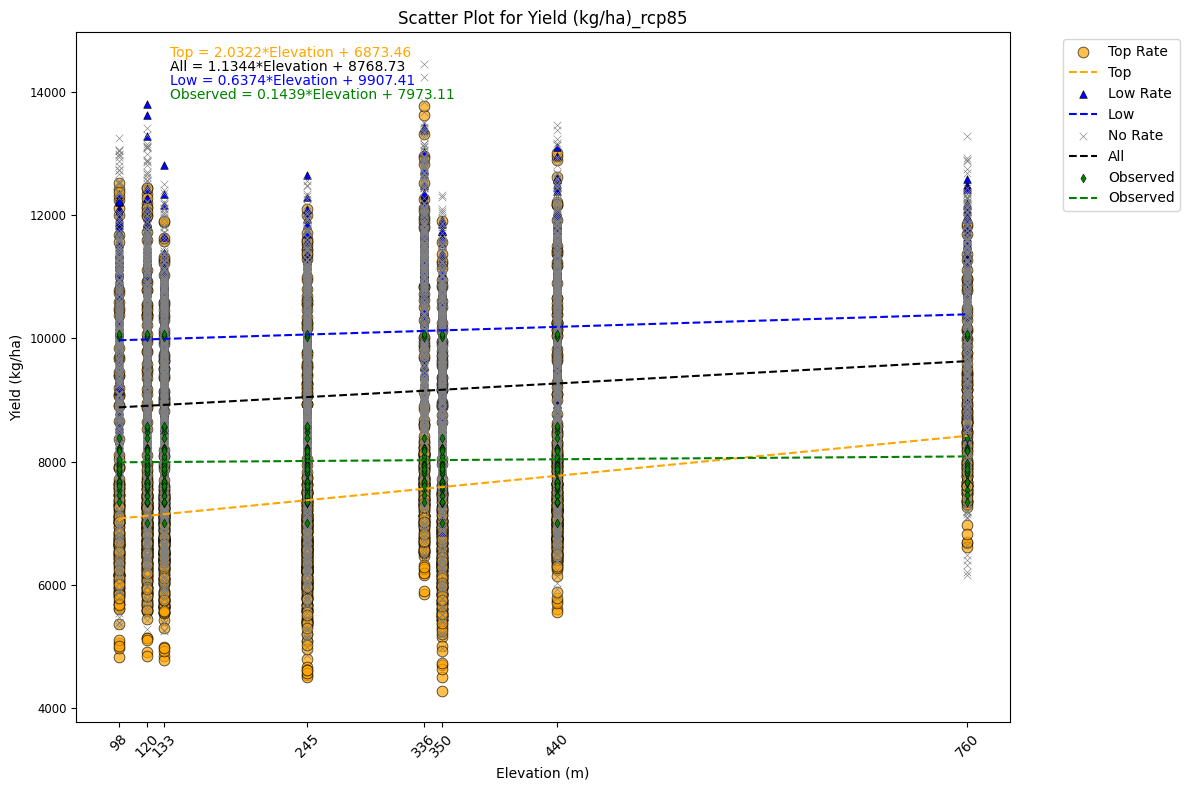

In [83]:
#%%script echo skipping
#@title Regression plots according to top-low Rate and Elevation
import pandas as pd
import os
os.chdir('/content/drive/MyDrive/Comparisons')


import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Function to calculate metrics
def plot_regression_line_and_equation(x, y, label, color, text_x, text_y):
    model = LinearRegression()
    model.fit(x.values.reshape(-1, 1), y)
    line_x = np.linspace(x.min(), x.max(), 100)
    line_y = model.predict(line_x.reshape(-1, 1))

    # Plot regression line
    plt.plot(line_x, line_y, color=color, linestyle='--', label=f'{label}')

    # Display equation with custom position
    slope = model.coef_[0]
    intercept = model.intercept_
    equation = f"{label} = {slope:.4f}*Elevation + {intercept:.2f}"
    plt.text(text_x, text_y, equation, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', color=color)



# Directory containing CSV files
DSSAT_directory = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS'
os.makedirs(DSSAT_directory, exist_ok=True)

combined_file_path = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_'+pdate+'.csv'
graphs_path = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/Graphs/'+pdate
df = pd.read_csv(combined_file_path)

# List of scenarios
scenarios = ['rcp26', 'rcp45', 'rcp85']

# Custom palette with 'top' as Orange and 'low' as Blue
custom_palette = {'top': 'orange', 'low': 'blue', 'other':'grey','Observed':'green'}

# Mapping of variables to y-axis labels
variable_labels = {'ADAT_day': 'Anthesis (Julian date)',
                   'MDAT_day': 'Maturity (Julian date)',
                   'HWAM': 'Yield (kg/ha)'}


for scenario in scenarios:
    for column in ['ADAT_day', 'MDAT_day', 'HWAM']:
        plt.figure(figsize=(12, 8))
        # Create scatter plot for 'top' Rate

        sns.scatterplot(x='Elevation', y=column, data=df[df['Rate'] == 'top'], color='orange', label='Top Rate', s=60, alpha=0.7, edgecolor='black', marker='o')
        plot_regression_line_and_equation(df[df['Rate'] == 'top']['Elevation'], df[df['Rate'] == 'top'][column], 'Top', 'orange', text_x=0.1, text_y=0.98)

        # Create scatter plot for 'low' Rate
        sns.scatterplot(x='Elevation', y=column, data=df[df['Rate'] == 'low'], color='blue', label='Low Rate', s=30, alpha=1, edgecolor='black', marker='^')
        plot_regression_line_and_equation(df[df['Rate'] == 'low']['Elevation'], df[df['Rate'] == 'low'][column], 'Low', 'blue', text_x=0.1, text_y=0.94)

        sns.scatterplot(x='Elevation', y=column, data=df[df['Rate'] == 'other'], color='grey', label='No Rate', s=30, alpha=1, edgecolor='grey', marker='x')
        plot_regression_line_and_equation(df['Elevation'], df[column], 'All', 'black', text_x=0.1, text_y=0.96)

        sns.scatterplot(x='Elevation', y=column, data=df[df['Rate'] == 'Observed'], color='green', label='Observed', s=20, alpha=1, edgecolor='black', marker='d')
        plot_regression_line_and_equation(df[df['Rate'] == 'Observed']['Elevation'], df[df['Rate'] == 'Observed'][column], 'Observed', 'green', text_x=0.1, text_y=0.92)

        plt.title('Scatter Plot for '+variable_labels[column]+'_'+scenario)
        plt.xlabel('Elevation (m)')
        plt.ylabel(variable_labels[column])  # Replace 'Your_Y_Column' with the actual column name you want on the y-axis

        # Set x-axis ticks as integers
        plt.xticks(df['Elevation'].unique().astype(int), rotation=45)

        # Rotate and make y-axis ticks smaller
        plt.yticks(fontsize='small')

        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()

        # Save the plot
        plot_filename = column+'_'+scenario+'_'+'Elevation_scatter.png'
        plot_filepath = os.path.join(graphs_path, plot_filename)
        plt.savefig(plot_filepath,dpi=600)
        plt.show()
        plt.close()

In [84]:
#@title Summary files t test for all Rate
%%script echo skipping

!pip install python-docx

import pandas as pd
from docx import Document
from scipy.stats import ttest_ind

# Assuming your CSV files have columns named 'ADAT', 'MDAT', and 'HWAM' containing the values to be compared
columns_to_compare = ['ADAT_day', 'MDAT_day', 'HWAM']

# List of data and corresponding labels
data_list = []
labels = []

# Load the CSV files into Pandas DataFrames
file_paths = [
    '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_Dec_01.csv',
    '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_Dec_16.csv',
    '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_Nov_15.csv'
]

for file_path in file_paths:
    file_data = pd.read_csv(file_path)
    labels.append('_'.join(os.path.splitext(os.path.basename(file_path))[0].split('_')[-2:]))
  # Extracting the filename without extension
    data_list.append(file_data[columns_to_compare])

# Create a Word document
doc = Document()

# Perform t-test for every pair combination and for each column
for column in columns_to_compare:
    doc.add_heading(f"Results for {column}:", level=1)

    for i in range(len(data_list)):
        for j in range(i+1, len(data_list)):
            group1 = data_list[i][column]
            group2 = data_list[j][column]
            label1 = labels[i]
            label2 = labels[j]

            # Perform t-test
            t_statistic, p_value = ttest_ind(group1, group2)


            # Add results to the Word document
            doc.add_heading(f"T-test between {label1} and {label2}:", level=2)
            doc.add_paragraph(f"T-statistic: {t_statistic}")
            doc.add_paragraph(f"P-value: {p_value:0.3e}")

            # Check for significance
            alpha = 0.05
            if p_value < alpha:
                doc.add_paragraph(f"{p_value:0.3e} < alpha={alpha}")
                doc.add_paragraph("There are statistically significant differences between the groups.")
            else:
                doc.add_paragraph(f"{p_value:0.3e} > alpha={alpha}")
                doc.add_paragraph("There are no statistically significant differences between the groups.")

            doc.add_paragraph("-" * 30)

# Save the Word document
doc.save('/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/t_test_results.docx')


skipping


In [85]:
#@title Summary files t test for top Rate
%%script echo skipping

!pip install python-docx

import pandas as pd
from docx import Document
from scipy.stats import ttest_ind

# Assuming your CSV files have columns named 'ADAT', 'MDAT', and 'HWAM' containing the values to be compared
columns_to_compare = ['ADAT_day', 'MDAT_day', 'HWAM']

# List of data and corresponding labels
data_list = []
labels = []

# Load the CSV files into Pandas DataFrames
file_paths = [
    '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_Dec_01.csv',
    '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_Dec_16.csv',
    '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_Nov_15.csv'
]

for file_path in file_paths:
    file_data = pd.read_csv(file_path)
    labels.append('_'.join(os.path.splitext(os.path.basename(file_path))[0].split('_')[-2:]))
  # Extracting the filename without extension
    data_list.append(file_data[file_data['Rate'] == 'top'][columns_to_compare])

# Create a Word document
doc = Document()

# Perform t-test for every pair combination and for each column
for column in columns_to_compare:
    doc.add_heading(f"Results for {column}:", level=1)

    for i in range(len(data_list)):
        for j in range(i+1, len(data_list)):
            group1 = data_list[i][column]
            group2 = data_list[j][column]
            label1 = labels[i]
            label2 = labels[j]

            # Perform t-test
            t_statistic, p_value = ttest_ind(group1, group2)


            # Add results to the Word document
            doc.add_heading(f"T-test between {label1} and {label2} for Rate=top:", level=2)
            doc.add_paragraph(f"T-statistic: {t_statistic}")
            doc.add_paragraph(f"P-value: {p_value:0.3e}")

            # Check for significance
            alpha = 0.05
            if p_value < alpha:
                doc.add_paragraph(f"{p_value:0.3e} < alpha={alpha}")
                doc.add_paragraph("There are statistically significant differences between the groups.")
            else:
                doc.add_paragraph(f"{p_value:0.3e} > alpha={alpha}")
                doc.add_paragraph("There are no statistically significant differences between the groups.")

            doc.add_paragraph("-" * 30)

# Save the Word document
doc.save('/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/t_test_top_results.docx')


skipping


In [86]:
#@title Summary files t test for low Rate
%%script echo skipping

!pip install python-docx

import pandas as pd
from docx import Document
from scipy.stats import ttest_ind

# Assuming your CSV files have columns named 'ADAT', 'MDAT', and 'HWAM' containing the values to be compared
columns_to_compare = ['ADAT_day', 'MDAT_day', 'HWAM']

# List of data and corresponding labels
data_list = []
labels = []

# Load the CSV files into Pandas DataFrames
file_paths = [
    '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_Dec_01.csv',
    '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_Dec_16.csv',
    '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_Nov_15.csv'
]

for file_path in file_paths:
    file_data = pd.read_csv(file_path)
    labels.append('_'.join(os.path.splitext(os.path.basename(file_path))[0].split('_')[-2:]))
  # Extracting the filename without extension
    data_list.append(file_data[file_data['Rate'] == 'low'][columns_to_compare])

# Create a Word document
doc = Document()

# Perform t-test for every pair combination and for each column
for column in columns_to_compare:
    doc.add_heading(f"Results for {column}:", level=1)

    for i in range(len(data_list)):
        for j in range(i+1, len(data_list)):
            group1 = data_list[i][column]
            group2 = data_list[j][column]
            label1 = labels[i]
            label2 = labels[j]

            # Perform t-test
            t_statistic, p_value = ttest_ind(group1, group2)


            # Add results to the Word document
            doc.add_heading(f"T-test between {label1} and {label2} for Rate=low:", level=2)
            doc.add_paragraph(f"T-statistic: {t_statistic}")
            doc.add_paragraph(f"P-value: {p_value:0.3e}")

            # Check for significance
            alpha = 0.05
            if p_value < alpha:
                doc.add_paragraph(f"{p_value:0.3e} < alpha={alpha}")
                doc.add_paragraph("There are statistically significant differences between the groups.")
            else:
                doc.add_paragraph(f"{p_value:0.3e} > alpha={alpha}")
                doc.add_paragraph("There are no statistically significant differences between the groups.")

            doc.add_paragraph("-" * 30)

# Save the Word document
doc.save('/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/t_test_low_results.docx')


skipping


In [87]:
#@title Summary files Kolmogorov-Smirnov test
%%script echo skipping

!pip install python-docx
import pandas as pd
from docx import Document
from scipy.stats import ks_2samp

# Assuming your CSV files have columns named 'ADAT', 'MDAT', and 'HWAM' containing the values to be compared
columns_to_compare = ['ADAT_day', 'MDAT_day', 'HWAM']

# List of data and corresponding labels
data_list = []
labels = []

# Load the CSV files into Pandas DataFrames
file_paths = [
    '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_Dec_01.csv',
    '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_Dec_16.csv',
    '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_Nov_15.csv'
]

for file_path in file_paths:
    file_data = pd.read_csv(file_path)
    labels.append('_'.join(os.path.splitext(os.path.basename(file_path))[0].split('_')[-2:]))
  # Extracting the filename without extension
    data_list.append(file_data[columns_to_compare])

# Create a Word document
doc = Document()

# Perform Kolmogorov-Smirnov test for every pair combination and for each column
for column in columns_to_compare:
    doc.add_heading(f"Results for {column}:", level=1)

    for i in range(len(data_list)):
        for j in range(i+1, len(data_list)):
            group1 = data_list[i][column]
            group2 = data_list[j][column]
            label1 = labels[i]
            label2 = labels[j]

            # Perform Kolmogorov-Smirnov test
            ks_statistic, p_value = ks_2samp(group1, group2)


            # Add results to the Word document with bold text
            doc.add_heading(f"Kolmogorov-Smirnov test between {label1} and {label2} for {column}:", level=2)
            doc.add_paragraph(f"KS-statistic: {ks_statistic}")
            doc.add_paragraph(f"P-value: {p_value:0.3e}")

            # Make P-value bold
            p_value_paragraph = doc.add_paragraph()
            for run in p_value_paragraph.runs:
                run.bold = True

            # Check for significance
            alpha = 0.05
            significance_paragraph = doc.add_paragraph()
            if p_value < alpha:
                significance_paragraph.add_run(f"{p_value:0.3e} < alpha={alpha}")
                significance_paragraph.add_run("\n There are significant differences between the distributions.")
            else:
                significance_paragraph.add_run(f"{p_value:0.3e} > alpha={alpha}")
                significance_paragraph.add_run("\n There are no significant differences between the distributions.")

            doc.add_paragraph("-" * 30)

# Save the Word document
doc.save('/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/ks_test_results.docx')


skipping


In [88]:
#@title Summary files Kolmogorov-Smirnov test top
%%script echo skipping

!pip install python-docx
import pandas as pd
from docx import Document
from scipy.stats import ks_2samp

# Assuming your CSV files have columns named 'ADAT', 'MDAT', and 'HWAM' containing the values to be compared
columns_to_compare = ['ADAT_day', 'MDAT_day', 'HWAM']

# List of data and corresponding labels
data_list = []
labels = []

# Load the CSV files into Pandas DataFrames
file_paths = [
    '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_Dec_01.csv',
    '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_Dec_16.csv',
    '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_Nov_15.csv'
]

for file_path in file_paths:
    file_data = pd.read_csv(file_path)
    labels.append('_'.join(os.path.splitext(os.path.basename(file_path))[0].split('_')[-2:]))
  # Extracting the filename without extension
    data_list.append(file_data[file_data['Rate'] == 'top'][columns_to_compare])

# Create a Word document
doc = Document()

# Perform Kolmogorov-Smirnov test for every pair combination and for each column
for column in columns_to_compare:
    doc.add_heading(f"Results for {column}:", level=1)

    for i in range(len(data_list)):
        for j in range(i+1, len(data_list)):
            group1 = data_list[i][column]
            group2 = data_list[j][column]
            label1 = labels[i]
            label2 = labels[j]

            # Perform Kolmogorov-Smirnov test
            ks_statistic, p_value = ks_2samp(group1, group2)


            # Add results to the Word document with bold text
            doc.add_heading(f"Kolmogorov-Smirnov test between {label1} and {label2} for {column}:", level=2)
            doc.add_paragraph(f"KS-statistic: {ks_statistic}")
            doc.add_paragraph(f"P-value: {p_value:0.3e}")

            # Make P-value bold
            p_value_paragraph = doc.add_paragraph()
            for run in p_value_paragraph.runs:
                run.bold = True

            # Check for significance
            alpha = 0.05
            significance_paragraph = doc.add_paragraph()
            if p_value < alpha:
                significance_paragraph.add_run(f"{p_value:0.3e} < alpha={alpha}")
                significance_paragraph.add_run("\n There are significant differences between the distributions.")
            else:
                significance_paragraph.add_run(f"{p_value:0.3e} > alpha={alpha}")
                significance_paragraph.add_run("\n There are no significant differences between the distributions.")

            doc.add_paragraph("-" * 30)

# Save the Word document
doc.save('/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/ks_test_top_results.docx')


skipping


In [89]:
#@title Summary files Kolmogorov-Smirnov test low
%%script echo skipping

!pip install python-docx
import pandas as pd
from docx import Document
from scipy.stats import ks_2samp

# Assuming your CSV files have columns named 'ADAT', 'MDAT', and 'HWAM' containing the values to be compared
columns_to_compare = ['ADAT_day', 'MDAT_day', 'HWAM']

# List of data and corresponding labels
data_list = []
labels = []

# Load the CSV files into Pandas DataFrames
file_paths = [
    '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_Dec_01.csv',
    '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_Dec_16.csv',
    '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_Nov_15.csv'
]

for file_path in file_paths:
    file_data = pd.read_csv(file_path)
    labels.append('_'.join(os.path.splitext(os.path.basename(file_path))[0].split('_')[-2:]))
  # Extracting the filename without extension
    data_list.append(file_data[file_data['Rate'] == 'low'][columns_to_compare])

# Create a Word document
doc = Document()

# Perform Kolmogorov-Smirnov test for every pair combination and for each column
for column in columns_to_compare:
    doc.add_heading(f"Results for {column}:", level=1)

    for i in range(len(data_list)):
        for j in range(i+1, len(data_list)):
            group1 = data_list[i][column]
            group2 = data_list[j][column]
            label1 = labels[i]
            label2 = labels[j]

            # Perform Kolmogorov-Smirnov test
            ks_statistic, p_value = ks_2samp(group1, group2)


            # Add results to the Word document with bold text
            doc.add_heading(f"Kolmogorov-Smirnov test between {label1} and {label2} for {column}:", level=2)
            doc.add_paragraph(f"KS-statistic: {ks_statistic}")
            doc.add_paragraph(f"P-value: {p_value:0.3e}")

            # Make P-value bold
            p_value_paragraph = doc.add_paragraph()
            for run in p_value_paragraph.runs:
                run.bold = True

            # Check for significance
            alpha = 0.05
            significance_paragraph = doc.add_paragraph()
            if p_value < alpha:
                significance_paragraph.add_run(f"{p_value:0.3e} < alpha={alpha}")
                significance_paragraph.add_run("\n There are significant differences between the distributions.")
            else:
                significance_paragraph.add_run(f"{p_value:0.3e} > alpha={alpha}")
                significance_paragraph.add_run("\n There are no significant differences between the distributions.")

            doc.add_paragraph("-" * 30)
            print(ks_2samp(group1, group2))

# Save the Word document
doc.save('/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/ks_test_low_results.docx')


skipping


In [90]:
#@title Differences files
%%script echo skipping
import pandas as pd

# Load the CSV files into Pandas DataFrames
file_nov_15 = pd.read_csv('/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_Nov_15.csv')
file_dec_01 = pd.read_csv('/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_Dec_01.csv')
file_dec_16 = pd.read_csv('/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/combined_data_Dec_16.csv')

# Columns to compare
columns_to_compare = ['ADAT_day', 'MDAT_day', 'HWAM']

# Calculate differences based on column type
diff_nov_15_dec_01 = pd.concat([
    100 * (file_nov_15[col] - file_dec_01[col]) / file_dec_01[col] if col == 'HWAM'
    else file_nov_15[col] - file_dec_01[col]
    for col in columns_to_compare
], axis=1)
# Calculate differences based on column type
diff_dec_16_dec_01 = pd.concat([
    100 * (file_dec_16[col] - file_dec_01[col]) / file_dec_01[col] if col == 'HWAM'
    else file_dec_16[col] - file_dec_01[col]
    for col in columns_to_compare
], axis=1)

# Combine the results into a new DataFrame
differences_df = pd.concat([diff_nov_15_dec_01.add_suffix(' (Nov 15)'), diff_dec_16_dec_01.add_suffix(' (Dec 16)')], axis=1)
# Rename specific columns
column_mapping = {
    'ADAT_day (Nov 15)': 'Anthesis date (Nov 15)',
    'MDAT_day (Nov 15)': 'Maturity date (Nov 15)',
    'HWAM (Nov 15)': 'Yield (Nov 15)',
    'ADAT_day (Dec 16)': 'Anthesis date (Dec 16)',
    'MDAT_day (Dec 16)': 'Maturity date (Dec 16)',
    'HWAM (Dec 16)': 'Yield (Dec 16)'
}

differences_df.rename(columns=column_mapping, inplace=True)

# Add additional columns
differences_df['Year'] = file_dec_01['Year']
differences_df['Location'] = file_dec_01['Location']
differences_df['Elevation'] = file_dec_01['Elevation']
differences_df['Climate_model'] = file_dec_01['Climate_model']
differences_df['Scenario'] = file_dec_01['Scenario']
differences_df['Rate'] = file_dec_01['Rate']

# Save the differences to a new CSV file
differences_df.to_csv('/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/differences.csv', index=False)


skipping


In [91]:
#@title Differences Boxplots per Year
%%script echo skipping
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the differences CSV file
differences_df = pd.read_csv('/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/differences.csv')
graphs_path = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/Graphs'
# Variables to plot
variables_to_plot = ['ADAT_day', 'MDAT_day', 'HWAM']

# Handle non-finite values in 'Year' column
differences_df['Year'] = pd.to_numeric(differences_df['Year'], errors='coerce')

# Drop rows with non-finite values in 'Year' column
differences_df = differences_df.dropna(subset=['Year'])

# Convert 'Year' column to integers
differences_df['Year'] = differences_df['Year'].astype(int)

# Set the style of the visualization
sns.set(style="whitegrid")

# Iterate through each variable
for variable in variables_to_plot:
    # Melt the DataFrame to create a common structure for boxplots
    melted_df = pd.melt(differences_df, id_vars=['Year'], value_vars=[f'{variable}_Nov_15', f'{variable}_Dec_16'],
                        var_name='Planting Dates', value_name='Values')

    plt.figure(figsize=(12, 6))

    # Boxplot for each planting date
    sns.boxplot(x='Year', y='Values', hue='Planting Dates', data=melted_df,
                palette=['blue', 'orange'], width=0.6)

    # Add legend
    plt.legend(bbox_to_anchor=(1.25, 1),title='Planting dates', loc='upper right')

    variable_name = variable.split('_')[0]

    # Adjust the layout
    plt.title(f'Boxplot for {variable_name} differences from December 01')
    plt.xlabel('Year')
    # Adjust ylabel based on variable_name
    if variable_name in ['ADAT', 'MDAT']:
        plt.ylabel(f'{variable_name} (days)')
    else:
        plt.ylabel(f'{variable_name} (%)')

    # Customize x-axis labels
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # Save the plot
    plot_filename = variable_name+'_'+'differences.png'
    plot_filepath = os.path.join(graphs_path, plot_filename)
    plt.savefig(plot_filepath,dpi=600)
    plt.show()
    plt.close()


skipping


In [92]:
#@title Differences Boxplots per Climate model
%%script echo skipping
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the differences CSV file
differences_df = pd.read_csv('/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/differences.csv')
graphs_path = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/Graphs'
# Variables to plot
variables_to_plot = ['ADAT_day', 'MDAT_day', 'HWAM']

# Handle non-finite values in 'Year' column
differences_df['Year'] = pd.to_numeric(differences_df['Year'], errors='coerce')

# Drop rows with non-finite values in 'Year' column
differences_df = differences_df.dropna(subset=['Year'])

# Convert 'Year' column to integers
differences_df['Year'] = differences_df['Year'].astype(int)

# Set the style of the visualization
sns.set(style="whitegrid")

# Iterate through each variable
for variable in variables_to_plot:
    # Melt the DataFrame to create a common structure for boxplots
    melted_df = pd.melt(differences_df, id_vars=['Climate_model'], value_vars=[f'{variable}_Nov_15', f'{variable}_Dec_16'],
                        var_name='Planting Dates', value_name='Values')

    plt.figure(figsize=(12, 6))

    # Boxplot for each planting date
    sns.boxplot(x='Climate_model', y='Values', hue='Planting Dates', data=melted_df,
                palette=['blue', 'orange'], width=0.6)

    # Add legend
    plt.legend(bbox_to_anchor=(1.25, 1),title='Planting dates', loc='upper right')

    variable_name = variable.split('_')[0]

    # Adjust the layout
    plt.title(f'Boxplot for {variable_name} differences from December 01')
    plt.xlabel('Climate_model')
    # Adjust ylabel based on variable_name
    if variable_name in ['ADAT', 'MDAT']:
        plt.ylabel(f'{variable_name} (days)')
    else:
        plt.ylabel(f'{variable_name} (%)')

    # Customize x-axis labels
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # Save the plot
    plot_filename = variable_name+'_'+'differences.png'
    plot_filepath = os.path.join(graphs_path, plot_filename)
    plt.savefig(plot_filepath,dpi=600)
    plt.show()
    plt.close()


skipping


In [93]:
#@title Differences Boxplots per climate model rating
%%script echo skipping
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu


# Load the differences CSV file
differences_df = pd.read_csv('/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/differences.csv')
graphs_path = '/content/drive/MyDrive/Comparisons/DSSAT_RESULTS/Graphs'
# Variables to plot
variables_to_plot = ['Anthesis date', 'Maturity date', 'Yield']

# Create a new DataFrame by concatenating Rate=top and Rate=low rows
new_df = pd.concat([differences_df[differences_df['Rate'] == 'top'], differences_df[differences_df['Rate'] == 'low']], ignore_index=True)
# Replace all values in the 'Rate' column with 'all'
differences_df['Rate'] = 'all'
# Create a new DataFrame by concatenating Rate=top and Rate=low rows
new_df2 = pd.concat([new_df,differences_df], ignore_index=True)

# Set the style of the visualization
sns.set(style="whitegrid")

# Iterate through each variable
for variable in variables_to_plot:
    # Melt the DataFrame to create a common structure for boxplots
    melted_df = pd.melt(new_df2, id_vars=['Rate'], value_vars=[f'{variable} (Nov 15)', f'{variable} (Dec 16)'],
                        var_name='Planting Dates', value_name='Values')



    plt.figure(figsize=(10, 6))

    # Boxplot for each planting date
    sns.boxplot(x='Rate', y='Values', hue='Planting Dates', data=melted_df,
                palette=['#1f77b4', '#ff7f0e'], width=0.4,
                flierprops={"marker":".", "markerfacecolor":"black", "markeredgecolor":"black"},
                showmeans=True,
                meanprops={"marker":"x", "markerfacecolor":"white", "markeredgecolor":"black"})


    # Add legend
    plt.legend(bbox_to_anchor=(1.35, 1),title='Planting dates', loc='upper right', fontsize=10)

    variable_name = variable.split('_')[0]

    # Adjust the layout
    plt.title(f'{variable_name} differences from those with planting date = December 01', fontweight='bold')
    plt.xlabel('Rate', fontweight='bold')
    # Adjust ylabel based on variable_name
    if variable_name in ['Anthesis date', 'Maturity date']:
        plt.ylabel(f'{variable_name} (Julian days)', fontweight='bold')
    else:
        plt.ylabel(f'{variable_name} (%)', fontweight='bold')

    # Customize x-axis labels
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    plt.tight_layout()

    # Save the plot
    plot_filename = variable_name+'_'+'differences_byrate.png'
    plot_filepath = os.path.join(graphs_path, plot_filename)
    plt.savefig(plot_filepath,dpi=600)
    plt.show()
    plt.close()


skipping
